# Responsible AI: Face Recognition
### Building a gender-neutral, race-agnostic age classifier for retail analytics

---

## Project Context
- **Problem:** Retail analytics systems need age estimation to understand customer demographics
- **Why Responsible AI:** Face images are highly sensitive personal data; systems trained on biased data produce biased outcomes
- **Who is affected:** Any person walking past a retail camera
- **Our Goal:** Build an age classifier whose performance is fair across all races and genders

## Design Decisions (fixed from Day 1)
- Race and gender are **never** used as model inputs
- Race and gender are kept **only** for fairness auditing after training
- No faces are stored — only age-group predictions are output
- System is for **academic research only** — not cleared for deployment

## Datasets & Roles

| Dataset | Role | Reason |
|---|---|---|
| UTKFace | Model training + per-group accuracy testing | Only dataset with continuous age labels plus race and gender |
| FairFace | Fairness testing (prediction consistency) | Balanced across 7 races — ideal bias audit set |
| Adience | **Dropped** | Too small (3,086 images), no race labels, coarse age brackets |

### Note on Dataset Roles
The project brief suggested FairFace as the training anchor with UTKFace/Adience as
held-out test sets. We instead trained on UTKFace (which provides continuous age labels
directly) and used FairFace for fairness testing across race groups, since the Kaggle
mirror of FairFace we accessed only provides race-labeled folders without the original
age/gender label files. This is a deliberate, documented adaptation.

## Licenses & Citations (verified)

**UTKFace** — Non-commercial research use only (official page confirmed).
Zhang, Z., Song, Y., & Qi, H. (2017). *Age Progression/Regression by Conditional
Adversarial Autoencoder.* CVPR 2017.

**FairFace** — CC BY 4.0 (confirmed on official GitHub repo).
Karkkainen, K., & Joo, J. (2021). *FairFace: Face Attribute Dataset for Balanced Race,
Gender, and Age for Bias Measurement and Mitigation.* WACV 2021, pp. 1548-1558.


## ⚡ Recovery Cell — run this first after any server restart
Reinstalls packages and reloads the saved model and data splits if they exist.
Skip straight to the fairness section if the checkpoint loads successfully.

In [37]:
# Recovery Cell — run first after a kernel/server restart.
# Reloads the saved model + data splits if they exist. Self-contained
# (defines its own paths) so it works before the config cell below.
import subprocess
for pkg in ["tensorflow", "kaggle"]:
    subprocess.run(["pip", "install", pkg, "-q"])

import os
import pandas as pd
from pathlib import Path

# Same environment detection as the Path Configuration cell.
_cloud   = Path("/home/jovyan/work/data")
WORK_DIR = _cloud if _cloud.exists() else Path(os.environ.get("FACE_DATA_ROOT", r"D:\nihal"))
MODEL_PATH = str(WORK_DIR / "age_classifier_baseline.keras")

if os.path.exists(MODEL_PATH):
    from tensorflow.keras.models import load_model
    model    = load_model(MODEL_PATH)
    train_df = pd.read_csv(str(WORK_DIR / "train_df.csv"))
    val_df   = pd.read_csv(str(WORK_DIR / "val_df.csv"))
    test_df  = pd.read_csv(str(WORK_DIR / "test_df.csv"))
    print("Checkpoint loaded from", WORK_DIR, "— model and splits restored")
else:
    print("No checkpoint at", MODEL_PATH, "— run the notebook from the top")

Checkpoint loaded from D:\nihal — model and splits restored


## Imports

In [38]:
%pip install seaborn

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.6 which is incompatible.
scipy 1.11.4 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.4.6 which is incompatible.
streamlit 1.37.0 requires packaging<25,>=20, but you have packaging 26.2 which is incompatible.
tensorflow-intel 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [39]:
import os
import json
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


In [40]:
# ============================================================
# Path Configuration  (environment-agnostic)
# Works unchanged in the cloud JupyterHub AND locally.
#   - Cloud: data lives under /home/jovyan/work/data
#   - Local: set FACE_DATA_ROOT, or it defaults to D:\nihal
# Every later cell uses WORK_DIR / the resolved dataset dirs,
# so there are NO hardcoded machine paths below this cell.
# ============================================================
from pathlib import Path
import os
import subprocess

CLOUD_DATA = Path("/home/jovyan/work/data")
LOCAL_ROOT = Path(os.environ.get("FACE_DATA_ROOT", r"D:\nihal"))

if CLOUD_DATA.exists():
    ENV, WORK_DIR = "cloud", CLOUD_DATA
else:
    ENV, WORK_DIR = "local", LOCAL_ROOT

WORK_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = str(WORK_DIR / "age_classifier_baseline.keras")

# Candidate layouts checked in order (cloud extraction layout vs local layout).
UTK_CANDIDATES = [
    CLOUD_DATA / "UTKFace" / "UTKFace",
    LOCAL_ROOT / "utkface",
    LOCAL_ROOT / "UTKFace" / "UTKFace",
]
FF_TRAIN_CANDIDATES = [
    CLOUD_DATA / "FairFace" / "FairFace Race" / "train",
    LOCAL_ROOT / "fairface" / "train",
]
FF_VAL_CANDIDATES = [
    CLOUD_DATA / "FairFace" / "FairFace Race" / "val",
    LOCAL_ROOT / "fairface" / "val",
]

def find_dir(candidates, what):
    for c in candidates:
        if Path(c).exists():
            return Path(c)
    raise FileNotFoundError(
        f"[{what}] not found. Looked in:\n  " +
        "\n  ".join(str(c) for c in candidates) +
        "\n\nFix: set FACE_DATA_ROOT to the folder holding your datasets.")

# If both datasets are already on disk, the download/extract cells will skip.
DATA_ALREADY_PRESENT = (
    any(Path(p).exists() for p in UTK_CANDIDATES) and
    any(Path(p).exists() for p in FF_TRAIN_CANDIDATES)
)

print(f"Environment          : {ENV}")
print(f"WORK_DIR             : {WORK_DIR}")
print(f"Data already present : {DATA_ALREADY_PRESENT}"
      f"  ({'download/extract cells will skip' if DATA_ALREADY_PRESENT else 'will download via Kaggle'})")

Environment          : local
WORK_DIR             : D:\nihal
Data already present : True  (download/extract cells will skip)


---
# WEEK 1 — Data Analysis, Planning, Architecture & Regulation
---

**Course goals for Week 1 (from the brief):**
1. Analyze the data
2. Derive a project plan from that analysis
3. Propose a possible architecture
4. Perform a regulatory analysis

**How this notebook covers each part (the sections below, in order):**

| Part | Section in this notebook | Goal it answers |
|---|---|---|
| A | Data Acquisition + Documentation | (context) which data, from where, under what licence |
| B | Data Loading + Cleaning & Privacy | prepares the data; bakes in GDPR data-minimization |
| C | Exploratory Data Analysis (EDA) — Findings 1-5 | **Goal 1: analyze the data** |
| D | Project Plan & Architecture | **Goals 2 & 3: plan + architecture** |
| E | Regulatory Analysis (GDPR + EU AI Act) | **Goal 4: regulatory analysis** |

*Everything runs top-to-bottom. Read the markdown between code cells — that is where the analysis and reasoning live.*

## Data Acquisition

### Credentials Setup

⚠️ **Privacy Notice:**
Kaggle API credentials live in a `kaggle.json` file inside your `WORK_DIR`
(cloud: `/home/jovyan/work/data/`  ·  local: your `FACE_DATA_ROOT`, e.g. `D:
ihal`).

This file:
- Is **never** committed to Git (listed in `.gitignore`)
- Is **never** hardcoded in this notebook
- Is only needed if the datasets are **not already on disk** — the download
  cells auto-skip when `DATA_ALREADY_PRESENT` is `True`.

To reproduce from scratch (no local data yet):
1. Create a Kaggle account → Settings → API → Create New Token
2. Save the downloaded `kaggle.json` into your `WORK_DIR`
3. Run the cells below — credentials load and datasets download automatically

In [41]:
%pip install kaggle -q
print("Kaggle installed")

Note: you may need to restart the kernel to use updated packages.
Kaggle installed


In [42]:
# Load Kaggle credentials only if we actually need to download (cloud / first run).
if not DATA_ALREADY_PRESENT:
    with open(str(WORK_DIR / "kaggle.json"), "r") as f:
        creds = json.load(f)
    os.environ["KAGGLE_USERNAME"] = creds["username"]
    os.environ["KAGGLE_KEY"]      = creds["key"]
    print("Kaggle credentials loaded — ready to download")
else:
    print("Data already present — skipping Kaggle credentials")

Data already present — skipping Kaggle credentials


### Download Datasets
Both downloads are idempotent — Kaggle skips files that already exist.
**Order matters:** download first, extract afterwards, so the notebook runs
top-to-bottom on a fresh server.

In [43]:
# Download UTKFace (training data) — skipped if already on disk.
if not DATA_ALREADY_PRESENT:
    subprocess.run(["kaggle", "datasets", "download",
                    "-d", "jangedoo/utkface-new", "-p", str(WORK_DIR)])
else:
    print("UTKFace already present — skipping download")

UTKFace already present — skipping download


In [44]:
# Download FairFace race mirror (fairness testing) — skipped if already on disk.
if not DATA_ALREADY_PRESENT:
    subprocess.run(["kaggle", "datasets", "download",
                    "-d", "abdulwasay551/fairface-race", "-p", str(WORK_DIR)])
    print(os.listdir(str(WORK_DIR)))
else:
    print("FairFace already present — skipping download")

FairFace already present — skipping download


### Extract Datasets

In [45]:
# Extract UTKFace — skipped if data already on disk (local).
if not DATA_ALREADY_PRESENT:
    shutil.rmtree(str(WORK_DIR / "UTKFace"), ignore_errors=True)
    with zipfile.ZipFile(str(WORK_DIR / "utkface-new.zip"), "r") as z:
        z.extractall(str(WORK_DIR / "UTKFace"))
    print("UTKFace extraction complete")
else:
    print("UTKFace already present — skipping extraction")

UTKFace already present — skipping extraction


In [46]:
# Extract FairFace — skipped if data already on disk (local).
if not DATA_ALREADY_PRESENT:
    shutil.rmtree(str(WORK_DIR / "FairFace"), ignore_errors=True)
    with zipfile.ZipFile(str(WORK_DIR / "fairface-race.zip"), "r") as z:
        z.extractall(str(WORK_DIR / "FairFace"))
    print("Extracted:", os.listdir(str(WORK_DIR / "FairFace")))
else:
    print("FairFace already present — skipping extraction")

FairFace already present — skipping extraction


In [47]:
# Sanity check on the UTKFace download (cloud / first run only).
if not DATA_ALREADY_PRESENT:
    with zipfile.ZipFile(str(WORK_DIR / "utkface-new.zip"), "r") as z:
        jpg_in_zip = sum(1 for f in z.namelist() if f.endswith(".jpg"))
    print("Total jpg files in zip:", jpg_in_zip)
    for root, dirs, files in os.walk(str(WORK_DIR / "UTKFace")):
        jpg_count = sum(1 for f in files if f.endswith(".jpg"))
        if jpg_count > 0:
            print(f"{root}: {jpg_count} jpg files")
else:
    print("Data already present — skipping zip sanity check")

Data already present — skipping zip sanity check


### Path Setup

In [48]:
# Resolve the dataset folders now that the data exists (extracted in the
# cloud, or already on disk locally). Robust to both folder layouts.
UTK_DIR        = find_dir(UTK_CANDIDATES,      "UTKFace image folder")
FAIRFACE_TRAIN = find_dir(FF_TRAIN_CANDIDATES, "FairFace train folder")
FAIRFACE_VAL   = find_dir(FF_VAL_CANDIDATES,   "FairFace val folder")

print("UTKFace images :", UTK_DIR)
print("FairFace train :", FAIRFACE_TRAIN)
print("FairFace val   :", FAIRFACE_VAL)

UTKFace images : D:\nihal\utkface
FairFace train : D:\nihal\fairface\train
FairFace val   : D:\nihal\fairface\val


## Dataset Documentation

### Dataset 1: UTKFace
- **Source:** University of Tennessee, Knoxville
- **Authors:** Zhang, Song & Qi — CVPR 2017
- **License:** Non-commercial research use only
- **Size:** ~23,700 images
- **Labels:** Age (0-116), Gender, Race — encoded in the filename as `age_gender_race_timestamp.jpg`
- **Role in this project:** Training the age classifier + per-group accuracy testing

⚠️ **License Restriction:**
UTKFace is available for **non-commercial research only**. This project is strictly
academic — no commercial deployment is made. Images are not redistributed or modified.

### Dataset 2: FairFace (Kaggle race-labeled mirror)
- **Source:** Karkkainen & Joo — WACV 2021
- **License:** CC BY 4.0 (confirmed on official GitHub)
- **Size:** ~108,000 images
- **Labels:** Race (7 categories) — encoded in the folder structure. **No age or gender labels in this mirror.**
- **Role in this project:** Fairness testing ONLY — never used for training

⚠️ **Known Limitation:**
FairFace images were sourced from the YFCC100M Flickr dataset. Individual subjects did
not explicitly consent to AI training use. This is a known ethical limitation of most
publicly available face datasets. In a real deployment, a lawful basis under GDPR would
be required (see Regulatory Analysis).

## Data Loading

### Load UTKFace
Labels are parsed from filenames: `age_gender_race_timestamp.jpg`.
Malformed filenames are skipped and counted.

In [49]:
RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}

rows    = []
skipped = 0

for img in sorted(UTK_DIR.iterdir()):
    if not img.name.endswith(".jpg"):
        skipped += 1
        continue
    parts = img.stem.split("_")
    if len(parts) < 3:                     # malformed filename — cannot parse labels
        skipped += 1
        continue
    try:
        rows.append({
            "filepath" : str(img),
            "age"      : int(parts[0]),
            "gender"   : GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race"     : RACE_MAP.get(int(parts[2]),   "Unknown"),
        })
    except ValueError:                     # non-numeric label — skip
        skipped += 1

df_utk = pd.DataFrame(rows)

print("UTKFace loaded :", len(df_utk), "images")
print("Skipped        :", skipped)
df_utk.head(3)

UTKFace loaded : 23705 images
Skipped        : 3


,filepath,age,gender,race
0,D:\nihal\utkface\100_0_0_20170112213500903.jpg...,100,Male,White
1,D:\nihal\utkface\100_0_0_20170112215240346.jpg...,100,Male,White
2,D:\nihal\utkface\100_1_0_20170110183726390.jpg...,100,Female,White


### Load FairFace
Race is encoded in the folder structure. The timestamp/identity portion of
filenames is never parsed or stored — only the filepath needed to load the image.

In [50]:
rows = []

for race_folder in sorted(FAIRFACE_TRAIN.iterdir()):
    for img in sorted(race_folder.glob("*.jpg")):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "train"})

for race_folder in sorted(FAIRFACE_VAL.iterdir()):
    for img in sorted(race_folder.glob("*.jpg")):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "val"})

df_fairface = pd.DataFrame(rows)

print("FairFace loaded :", len(df_fairface), "images")
print("Races           :", sorted(df_fairface["race"].unique()))
df_fairface.head(3)

FairFace loaded : 97698 images
Races           : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


,filepath,race,split
0,D:\nihal\fairface\train\Black\1001.jpg,Black,train
1,D:\nihal\fairface\train\Black\10010.jpg,Black,train
2,D:\nihal\fairface\train\Black\10011.jpg,Black,train


## Data Cleaning & Privacy

### Clean UTKFace
Filters applied:
- Age restricted to 1–100 (removes label errors like age 0 and 116)
- Rows with unknown gender or race removed
- Age binned into 9 groups for classification

In [51]:
# Canonical age-group order — used everywhere so plots and tables sort correctly
AGE_GROUP_LABELS = ["0-2", "3-9", "10-19", "20-29", "30-39",
                    "40-49", "50-59", "60-69", "70+"]

def age_to_group(age):
    if   age <= 2:  return "0-2"
    elif age <= 9:  return "3-9"
    elif age <= 19: return "10-19"
    elif age <= 29: return "20-29"
    elif age <= 39: return "30-39"
    elif age <= 49: return "40-49"
    elif age <= 59: return "50-59"
    elif age <= 69: return "60-69"
    else:           return "70+"

df_utk_clean = df_utk.copy()
df_utk_clean = df_utk_clean[df_utk_clean["age"] >= 1]
df_utk_clean = df_utk_clean[df_utk_clean["age"] <= 100]
df_utk_clean = df_utk_clean[df_utk_clean["gender"] != "Unknown"]
df_utk_clean = df_utk_clean[df_utk_clean["race"]   != "Unknown"]
df_utk_clean["age_group"] = df_utk_clean["age"].apply(age_to_group)

minors = (df_utk_clean["age"] < 18).sum()

print("Total cleaned images:", len(df_utk_clean))
print("Minors (age < 18)   :", minors)
print("Adults              :", len(df_utk_clean) - minors)
print()
print("Age group distribution:")
print(df_utk_clean["age_group"].value_counts().reindex(AGE_GROUP_LABELS))

Total cleaned images: 23684
Minors (age < 18)   : 4233
Adults              : 19451

Age group distribution:
age_group
0-2      1605
3-9      1457
10-19    1531
20-29    7344
30-39    4536
40-49    2245
50-59    2299
60-69    1316
70+      1351
Name: count, dtype: int64


### Clean FairFace

In [52]:
df_fairface_clean = df_fairface.copy()

# Step 1: keep only files that exist on disk
df_fairface_clean["exists"] = df_fairface_clean["filepath"].apply(os.path.exists)
df_fairface_clean = df_fairface_clean[df_fairface_clean["exists"]].drop(columns=["exists"])

# Step 2: remove nulls
df_fairface_clean = df_fairface_clean.dropna(subset=["race"])

# Step 3: keep only needed columns (data minimization)
df_fairface_clean = df_fairface_clean[["filepath", "race", "split"]]

print("FairFace after cleaning :", len(df_fairface_clean))
print("Races :", sorted(df_fairface_clean["race"].unique()))

FairFace after cleaning : 97698
Races : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


### GDPR Data Minimization Documentation (Article 5(1)(c))

**Columns DROPPED:**
- Timestamps from UTKFace filenames → no identity linking possible
- Adience `user_id` → entire dataset dropped
- Any metadata not required for the stated purpose

**Columns KEPT and why:**

| Column | Purpose |
|---|---|
| `age` | Prediction target — core purpose of the system |
| `race` | Bias auditing **only** — never fed into the model |
| `gender` | Fairness testing **only** — never fed into the model |
| `filepath` | Needed to load images — not stored after training |

**Children's data (GDPR Art. 8):** minors (age < 18) are present in UTKFace and are
retained for age diversity in training. In a real deployment, parental consent would be
required for anyone under 16 (Germany's threshold).

## Exploratory Data Analysis (EDA)

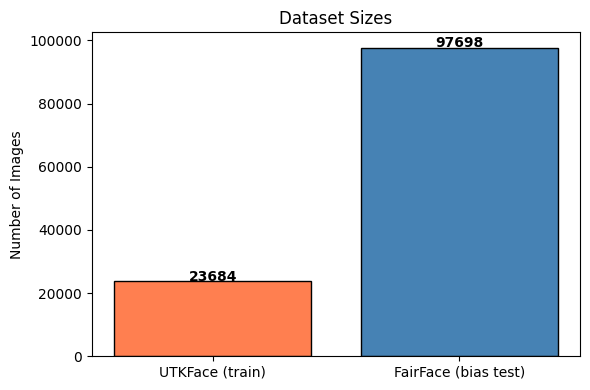

In [53]:
# Dataset sizes at a glance
counts = {"UTKFace (train)": len(df_utk_clean),
          "FairFace (bias test)": len(df_fairface_clean)}

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["coral", "steelblue"], edgecolor="black")
plt.title("Dataset Sizes")
plt.ylabel("Number of Images")
for i, v in enumerate(counts.values()):
    plt.text(i, v + 100, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### UTKFace Age Distribution

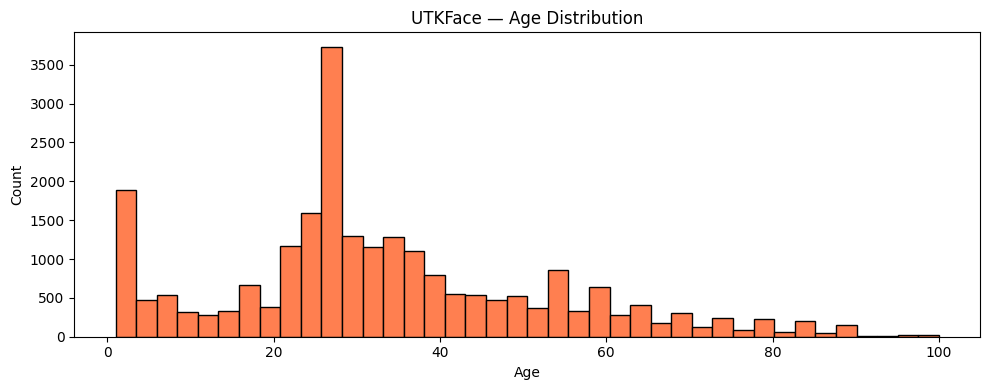

Min age : 1
Max age : 100
Mean age: 33.2


In [54]:
plt.figure(figsize=(10, 4))
plt.hist(df_utk_clean["age"], bins=40, color="coral", edgecolor="black")
plt.title("UTKFace — Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Min age :", df_utk_clean["age"].min())
print("Max age :", df_utk_clean["age"].max())
print("Mean age:", round(df_utk_clean["age"].mean(), 1))

#### Finding 1 — Age Distribution is Heavily Skewed
The histogram shows a strong concentration of faces aged **20-40**.
Faces aged 70+ are severely underrepresented relative to the 20-29 group
(1,351 vs 7,344 images).

**Why this matters:** the model sees far more young/middle-aged faces during training,
so it learns those age groups much better than elderly or infant faces.

**How we address it:** class weights during training make the model pay more attention
to underrepresented groups like 0-2, 60-69 and 70+.

### UTKFace Age Group Distribution

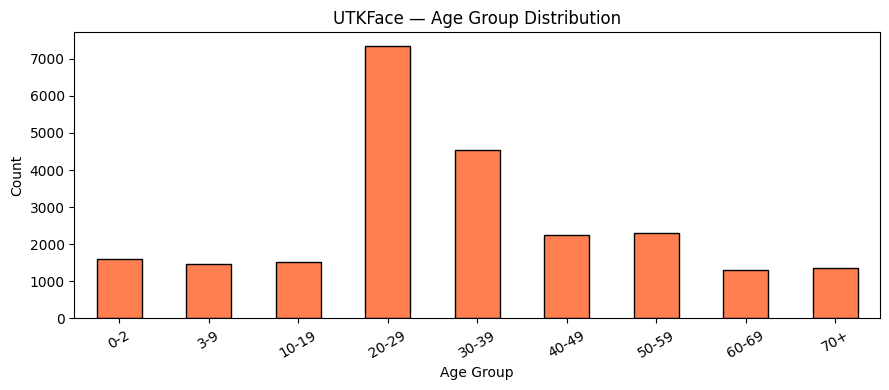

In [55]:
# reindex with AGE_GROUP_LABELS so bars appear in true age order
# (plain sort_index() would sort strings: "10-19" before "3-9")
plt.figure(figsize=(9, 4))
df_utk_clean["age_group"].value_counts().reindex(AGE_GROUP_LABELS).plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("UTKFace — Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### UTKFace Race Distribution

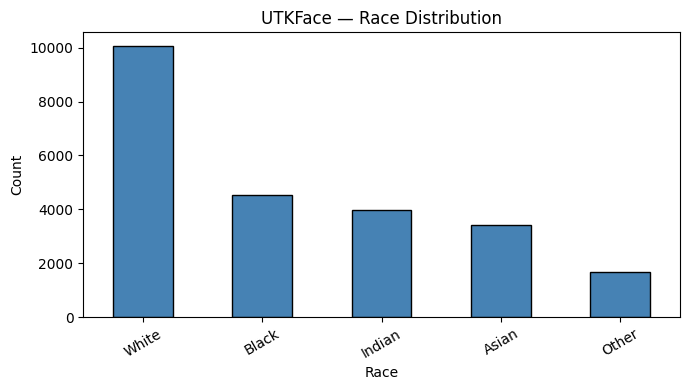

In [56]:
plt.figure(figsize=(7, 4))
df_utk_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("UTKFace — Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Finding 2 — White Faces Dominate UTKFace
White faces make up the largest group (~44%), followed by Black and Asian.
This is a known bias in datasets collected from Western internet sources.

**Why this matters:** a model trained on this imbalance may perform differently across
race categories.

**How we address it:** we measure per-race accuracy on the UTKFace test set and test
prediction consistency on FairFace, which is balanced across 7 races. Any gap we find
is quantified — not assumed.

### UTKFace Gender Distribution

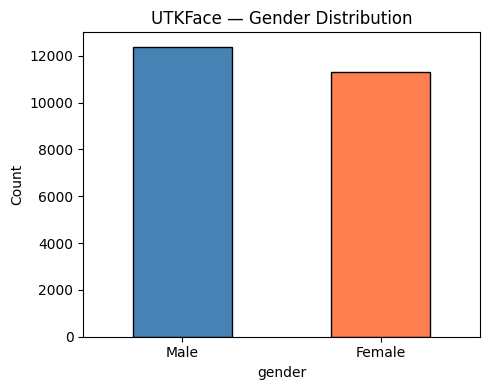

In [57]:
plt.figure(figsize=(5, 4))
df_utk_clean["gender"].value_counts().plot(
    kind="bar", color=["steelblue", "coral"], edgecolor="black"
)
plt.title("UTKFace — Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Finding 3 — Gender is Approximately Balanced
Male and female faces are roughly equal in UTKFace. This is a positive finding —
gender imbalance in training data is less of a concern.

**Note:** gender is never used as a model input. It is retained only to test whether
model accuracy differs by gender — measured in the Week 2 fairness analysis.

### FairFace Race Distribution

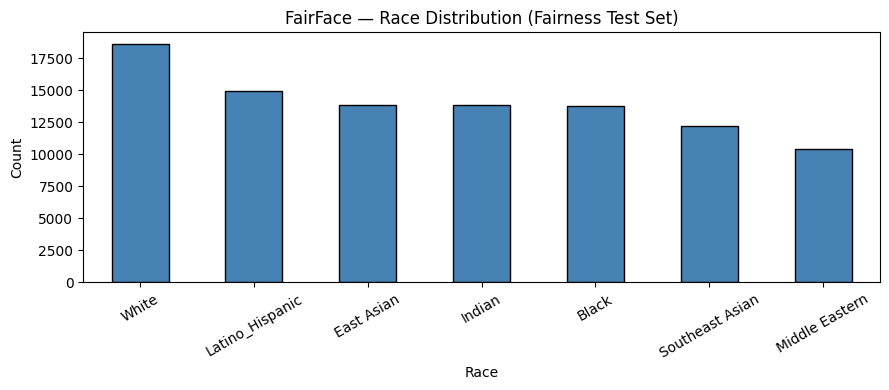

In [58]:
plt.figure(figsize=(9, 4))
df_fairface_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("FairFace — Race Distribution (Fairness Test Set)")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Finding 4 — FairFace is Well Balanced Across 7 Races
FairFace shows approximately equal representation across Black, East Asian, Indian,
Latino Hispanic, Middle Eastern, Southeast Asian and White.

**Why this is important:** this balance makes FairFace an ideal fairness test set.
Any differences in prediction behavior across races reflect model behavior — not
differences in how many examples of each race we tested.

### Bias Check: Age by Race

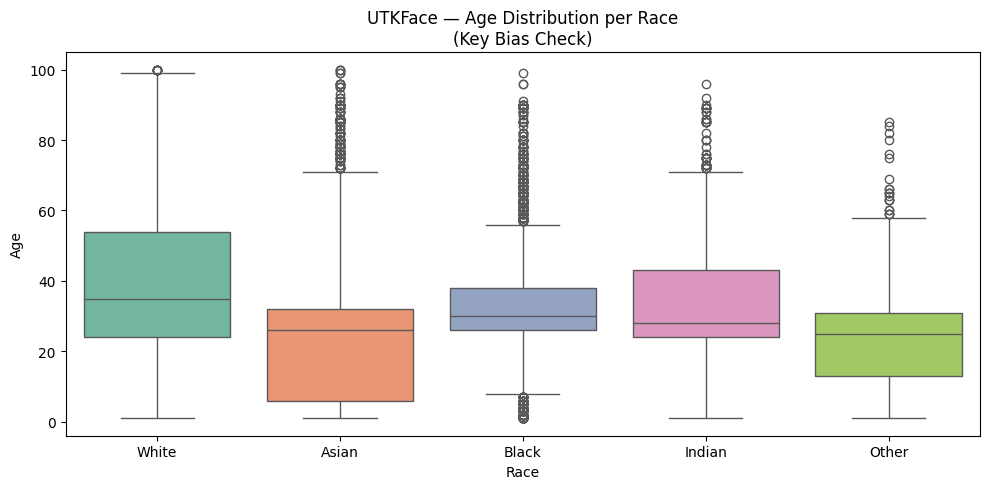

In [59]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_utk_clean, x="race", y="age", palette="Set2")
plt.title("UTKFace — Age Distribution per Race\n(Key Bias Check)")
plt.xlabel("Race")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

#### Finding 5 — Age Range Varies Across Races (Key Bias Risk)
The boxplot shows different age distributions across races in UTKFace. Some races have
fewer elderly or fewer young faces represented.

**What this means:** even with good overall accuracy, the model may fail on specific
age-race combinations that are underrepresented. If Indian elderly faces are rare in
training, the model may consistently predict Indian faces as younger than they are.

**This is the central fairness question our Week 2 analysis answers:**
does model accuracy differ systematically across race groups?

### Sample Images

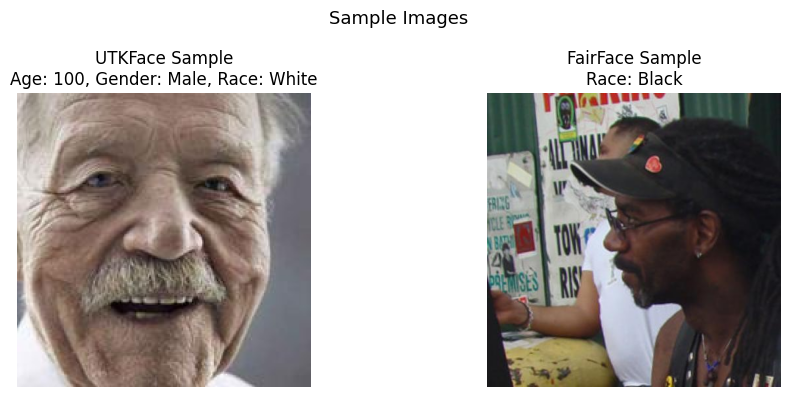

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

img1 = mpimg.imread(df_utk_clean["filepath"].iloc[0])
axes[0].imshow(img1)
axes[0].set_title(f"UTKFace Sample\nAge: {df_utk_clean['age'].iloc[0]}, "
                  f"Gender: {df_utk_clean['gender'].iloc[0]}, "
                  f"Race: {df_utk_clean['race'].iloc[0]}")
axes[0].axis("off")

img2 = mpimg.imread(df_fairface_clean["filepath"].iloc[0])
axes[1].imshow(img2)
axes[1].set_title(f"FairFace Sample\nRace: {df_fairface_clean['race'].iloc[0]}")
axes[1].axis("off")

plt.suptitle("Sample Images", fontsize=13)
plt.tight_layout()
plt.show()

### EDA Summary

| Finding | Impact on Model |
|---|---|
| Young faces (20-40) dominate UTKFace | Model may underperform on elderly and infants |
| White faces outnumber others in UTKFace | Potential accuracy differences across races |
| Gender approximately balanced | Lower gender-bias risk — still verified in Week 2 |
| FairFace balanced across 7 races | Clean fairness test set |
| Minors present in UTKFace (4,233 images) | Documented — special care required in deployment |
| Age 70+ very underrepresented | Class weights applied during training |

**Next step → project plan, architecture and regulatory analysis, then model building.**

## Week 1: Project Plan & Architecture

### Problem Statement
We are building an age classification system for retail analytics. The system estimates
a customer's age group from a face image and must work fairly across all races and genders.

### Dataset Decision

| Dataset | Role | Reason |
|---|---|---|
| UTKFace | Model training + per-group accuracy tests | Continuous age labels, race, gender — most complete |
| FairFace | Fairness testing | Balanced across 7 races — ideal for bias audit |
| Adience | Dropped | Too small (3,086 images), no race labels, rough age brackets |

### Why MobileNetV2
- Lightweight — designed for devices without powerful GPUs (matches our CPU-only server)
- Pretrained on ImageNet — already understands generic visual features
- Transfer learning means far less training data and compute is needed
- Widely used in production retail and mobile systems

### Race-Agnostic Design
- Race is **never** an input to the model
- Gender is **never** an input to the model
- The model sees only raw pixel values
- Fairness is measured after training on both UTKFace (accuracy) and FairFace (consistency)
- This prevents explicit use of protected attributes, while we still audit for implicit bias
  (the model can reconstruct race-correlated signal from pixels — see Risk R3)

### Training Strategy
- Full cleaned dataset: 23,684 images
- Split: 70% train / 15% validation / 15% test, **stratified on age group**
- Class weights compensate for imbalanced age groups
- Two-stage training: (1) frozen MobileNetV2 backbone, (2) fine-tune the last 30 layers
  at a low learning rate
- Optimizer: Adam · Loss: categorical cross-entropy · EarlyStopping on validation accuracy
- No data augmentation in the baseline — considered for Week 3 improvement

In [61]:
# Architecture diagram (display only)
from IPython.display import display, HTML

architecture_html = """
<div style="background:#f8f8f8; border-radius:12px; padding:20px; font-family:sans-serif; max-width:500px; margin:auto;">

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Input</b><br><span style="font-size:12px; color:#555;">Face image — 96×96 RGB</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Preprocessing</b><br>
    <span style="font-size:12px; color:#555;">Resize to 96×96 · Normalize pixels ÷ 255</span><br>
    <span style="font-size:11px; color:#c0392b;">⚠ Race & gender: never used as input</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>MobileNetV2 Backbone</b><br>
    <span style="font-size:12px; color:#555;">Pretrained ImageNet · Stage 1: frozen · Stage 2: last 30 layers fine-tuned</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fde8df; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>GlobalAveragePooling2D</b><br>
    <span style="font-size:12px; color:#555;">Compresses feature maps to a 1D vector</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fef3d6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dropout (0.5)</b><br>
    <span style="font-size:12px; color:#555;">Drops 50% of neurons — prevents overfitting</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 128 — ReLU</b><br>
    <span style="font-size:12px; color:#555;">Learns age-specific patterns</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 9 — Softmax</b><br>
    <span style="font-size:12px; color:#555;">One probability per age group</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px;">
    <b>Output: Age Group</b><br>
    <span style="font-size:11px; color:#555;">0-2 · 3-9 · 10-19 · 20-29 · 30-39 · 40-49 · 50-59 · 60-69 · 70+</span>
  </div>

</div>
"""

display(HTML(architecture_html))

---
## Week 1: Regulatory Analysis
---

Our system estimates a person's age group from a face image, intended for a retail
analytics context in the EU. Two regulations dominate: the **GDPR** and the **EU AI Act**.
We analyze both honestly, including where classification is genuinely ambiguous —
because getting the classification *right* matters more than defaulting to the
scariest label.

### 1. GDPR — General Data Protection Regulation (EU 2016/679)

**Are face images "biometric data" here?** Under Art. 4(14), biometric data is personal
data from technical processing of physical characteristics **which allows or confirms
the unique identification** of a person. Recital 51 clarifies that photographs are *not*
automatically special-category data — they become biometric data only when processed
through means that enable unique identification.

Our classifier does **not** identify anyone: it maps pixels to one of nine age groups
and discards the image. Strictly read, this may fall outside Art. 9 special-category
processing. However:

- The *training datasets* contain identifiable faces of real people who never consented
  to AI training use — that processing is squarely personal-data processing under GDPR.
- A deployed retail camera would capture images that *could* be used for identification,
  so a Data Protection Authority would likely apply the precautionary reading.

**We therefore treat the data as if Art. 9 applied** — the conservative position —
while documenting the legal nuance.

| Article | Requirement | How we address it |
|---|---|---|
| Art. 4(14) / Rec. 51 | Biometric-data definition | No unique identification performed; conservative Art. 9 treatment applied anyway |
| Art. 5(1)(c) | Data minimization | Only age (target), race and gender (audit-only), and filepath are retained; all other filename metadata dropped |
| Art. 5(1)(b) | Purpose limitation | Race/gender used exclusively for post-hoc fairness auditing, never as model input |
| Art. 6 / 9 | Lawful basis | Academic research context; no deployment. Commercial use would require explicit consent or another Art. 9(2) basis plus an Art. 6 basis |
| Art. 8 | Children's consent (Germany: 16) | Minors are present in UTKFace (4,233 images < 18). Retained for age-diversity in training; flagged as a hard deployment constraint |
| Art. 25 | Privacy by design | No face storage; aggregate age-group output only; protected attributes excluded from the model by construction |
| Art. 35 | DPIA | Systematic monitoring of a publicly accessible area with novel technology → DPIA mandatory before any real deployment |

### 2. EU AI Act (Regulation 2024/1689)

The classification question is subtler than it first appears, and we walk through it
explicitly:

**Prohibited (Art. 5)?** No. Art. 5(1)(g) prohibits biometric categorization that
*infers sensitive attributes* (race, political opinion, religion, sexual orientation…).
Age is not a sensitive attribute in this list, and our system is deliberately designed
**not** to infer race or gender. Real-time remote biometric *identification* in public
spaces (Art. 5(1)(h)) is also prohibited — we perform no identification.

**High-risk (Annex III)?** Annex III point 1(b) covers biometric categorization
*according to sensitive or protected attributes*. Age-group estimation does not
obviously fall under this. So unlike a naive reading, our system is **not clearly
high-risk** — but it is not clearly out of scope either, and guidance is still evolving.
A deployer should obtain a formal legal assessment.

**Transparency obligations (Art. 50)** apply in any case: people exposed to a biometric
categorization system must be informed of its operation. In a retail store this means
visible signage and accessible information — non-negotiable.

| Question | Answer |
|---|---|
| Prohibited practice? | No — no sensitive-attribute inference, no identification |
| High-risk (Annex III 1(b))? | Ambiguous — age is not a "sensitive or protected attribute"; conservative deployers should assume yes until guidance settles |
| Transparency (Art. 50)? | Yes — mandatory disclosure to affected persons |
| If treated as high-risk | Conformity assessment, risk-management system, per-demographic accuracy documentation, human oversight, EU database registration |

### 3. What this means for our project

This project is **research only**: no individuals are processed in real time, no faces
are stored or transmitted, no consequential decisions are made, and all results and
limitations are documented in this notebook. The per-demographic accuracy documentation
the AI Act would demand of a high-risk deployer is exactly what our Week 2 fairness
analysis produces — so our academic work doubles as the compliance groundwork a real
deployment would need.

### 4. Unresolved ethical tension

Both UTKFace and FairFace contain faces scraped from the internet without subject
consent (FairFace derives from YFCC100M/Flickr). This is a known, unresolved problem in
computer vision research. We use the data under its academic licenses (UTKFace:
non-commercial research only; FairFace: CC BY 4.0), acknowledge the tension explicitly,
and note that no commercial use of models trained on this data would be defensible
without establishing a lawful basis for the underlying processing.

---
# WEEK 2 — Baseline Model, Risk Analysis & Fairness
---

**Course goals for Week 2 (from the brief):**
1. Build a baseline model
2. Make a risk analysis
3. Analyze fairness in the system

**How this notebook covers each part (the sections below, in order):**

| Part | Section in this notebook | Goal it answers |
|---|---|---|
| A | Split · Config · Load Images · Class Weights | data prep for modelling |
| B | Build Model → Stage 1 (frozen) → Stage 2 (fine-tune) → Final Test | **Goal 1: baseline model** |
| C | Risk Analysis (R1-R8 matrix + worked examples) | **Goal 2: risk analysis** |
| D | Fairness Analysis (per-race / per-gender accuracy + FairFace consistency) | **Goal 3: fairness** |
| E | Save Checkpoint | reproducibility |

*Because this is a computer-vision project — new territory if your background is NLP / tabular ML — short "concept" cells are added before the image-specific steps. They connect each new idea to something you already know.*

In [62]:
%pip install tensorflow -q
print("Done")

Note: you may need to restart the kernel to use updated packages.
Done


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.3.3 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
langchain-community 0.4.2 requires numpy>=1.26.2; python_version < "3.13", but you have numpy 1.24.3 which is incompatible.
streamlit 1.37.0 requires packaging<25,>=20, but you have packaging 26.2 which is incompatible.


In [63]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.13.0
GPU available: []


### Age Groups (9 classes)

| Class | Age Range |
|---|---|
| 0 | 0-2 |
| 1 | 3-9 |
| 2 | 10-19 |
| 3 | 20-29 |
| 4 | 30-39 |
| 5 | 40-49 |
| 6 | 50-59 |
| 7 | 60-69 |
| 8 | 70+ |

### Train / Validation / Test Split
Stratified on the age-group label — ensures all age groups are represented
proportionally in each split, so the model is never evaluated on an
unrepresentative subset.

In [64]:
AGE_GROUP_MAP = {label: i for i, label in enumerate(AGE_GROUP_LABELS)}
NUM_CLASSES   = len(AGE_GROUP_MAP)

df_utk_clean["label"] = df_utk_clean["age_group"].map(AGE_GROUP_MAP)

train_df, temp_df = train_test_split(
    df_utk_clean,
    test_size=0.30,
    stratify=df_utk_clean["label"],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size :", len(train_df))
print("Val size   :", len(val_df))
print("Test size  :", len(test_df))

Train size : 16578
Val size   : 3553
Test size  : 3553


### Configuration
All hyperparameters live here and are used consistently below.

In [65]:
IMG_SIZE     = 96      # input resolution (CPU constraint — larger would be slow)
BATCH_SIZE   = 32
EPOCHS_S1    = 50      # stage 1: frozen backbone (EarlyStopping cuts this short)
EPOCHS_S2    = 30      # stage 2: fine-tuning
LR_STAGE1    = 1e-4
LR_STAGE2    = 1e-5    # much lower LR for fine-tuning — protects pretrained weights
SEED         = 42

print(f"Image size {IMG_SIZE} · Batch {BATCH_SIZE} · "
      f"Stage-1 epochs {EPOCHS_S1} · Stage-2 epochs {EPOCHS_S2}")

Image size 96 · Batch 32 · Stage-1 epochs 50 · Stage-2 epochs 30


### Load Images
Images loaded at 96×96 pixels, normalized to the 0-1 range. Loaded **once** here
and reused for both training stages and all evaluations.

In [66]:
def load_images(dataframe, img_size):
    images, labels = [], []
    for _, row in dataframe.iterrows():
        try:
            img = Image.open(row["filepath"]).convert("RGB")
            img = img.resize((img_size, img_size))
            images.append(np.array(img) / 255.0)
            labels.append(row["label"])
        except Exception:
            continue          # unreadable file — skip
    return np.array(images), to_categorical(labels, num_classes=NUM_CLASSES)

print("Loading train images...")
X_train, y_train = load_images(train_df, IMG_SIZE)

print("Loading val images...")
X_val, y_val = load_images(val_df, IMG_SIZE)

print("Loading test images...")
X_test, y_test = load_images(test_df, IMG_SIZE)

print("Shapes:")
print("  X_train:", X_train.shape)
print("  X_val  :", X_val.shape)
print("  X_test :", X_test.shape)

Loading train images...


Loading val images...
Loading test images...
Shapes:
  X_train: (16578, 96, 96, 3)
  X_val  : (3553, 96, 96, 3)
  X_test : (3553, 96, 96, 3)


### Class Weights
Applied to compensate for age-group imbalance. Rare groups (0-2, 60-69, 70+) get
higher weight so the model pays more attention to them during training.

In [67]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for k, v in class_weight_dict.items():
    print(f"  Class {k} ({AGE_GROUP_LABELS[k]:5s}): {v:.2f}")

Class weights:
  Class 0 (0-2  ): 1.64
  Class 1 (3-9  ): 1.81
  Class 2 (10-19): 1.72
  Class 3 (20-29): 0.36
  Class 4 (30-39): 0.58
  Class 5 (40-49): 1.17
  Class 6 (50-59): 1.14
  Class 7 (60-69): 2.00
  Class 8 (70+  ): 1.95


### Build the Model — Two-Stage Training Strategy

**Stage 1 — frozen backbone:** all MobileNetV2 layers frozen, only the new
classification head trains. This lets the head adapt to the age task without
destroying pretrained ImageNet features.

**Stage 2 — fine-tuning:** the last 30 backbone layers are unfrozen and trained
at a 10× lower learning rate. With 16.5k training images this is safe and gives
the backbone a chance to specialize on faces.

In [68]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Stage 1: keep ALL base layers frozen
base_model.trainable = False

# Classification head
x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dropout(0.5)(x)                       # heavy dropout — reduces overfitting
x      = Dense(128, activation="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_STAGE1),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Stage 1: Train with Frozen Backbone
EarlyStopping monitors validation accuracy and restores the best weights —
training stops automatically when validation stops improving.

In [69]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_S1,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
519/519 [==============================] - 113s 207ms/step - loss: 2.1828 - accuracy: 0.1980 - val_loss: 1.8020 - val_accuracy: 0.3118
Epoch 2/50
519/519 [==============================] - 98s 188ms/step - loss: 1.8050 - accuracy: 0.2760 - val_loss: 1.6715 - val_accuracy: 0.3406
Epoch 3/50
519/519 [==============================] - 97s 188ms/step - loss: 1.6809 - accuracy: 0.3160 - val_loss: 1.6372 - val_accuracy: 0.3569
Epoch 4/50
519/519 [==============================] - 98s 189ms/step - loss: 1.6242 - accuracy: 0.3313 - val_loss: 1.5951 - val_accuracy: 0.3690
Epoch 5/50
519/519 [==============================] - 98s 190ms/step - loss: 1.5703 - accuracy: 0.3475 - val_loss: 1.5461 - val_accuracy: 0.3907
Epoch 6/50
519/519 [==============================] - 123s 237ms/step - loss: 1.5429 - accuracy: 0.3578 - val_loss: 1.5539 - val_accuracy: 0.3833
Epoch 7/50
519/519 [==============================] - 114s 220ms/step - loss: 1.5235 - accuracy: 0.3673 - val_loss: 1.5211 - val

### Take 32 images from X_train.
### Push them through all layers and gets 32 predictions.
### Compare against truth → average loss over the 32 predictions.
### Compute gradients: which direction should each trainable weight move?
### Update every trainable weight 

### Stage 1 Training Curves

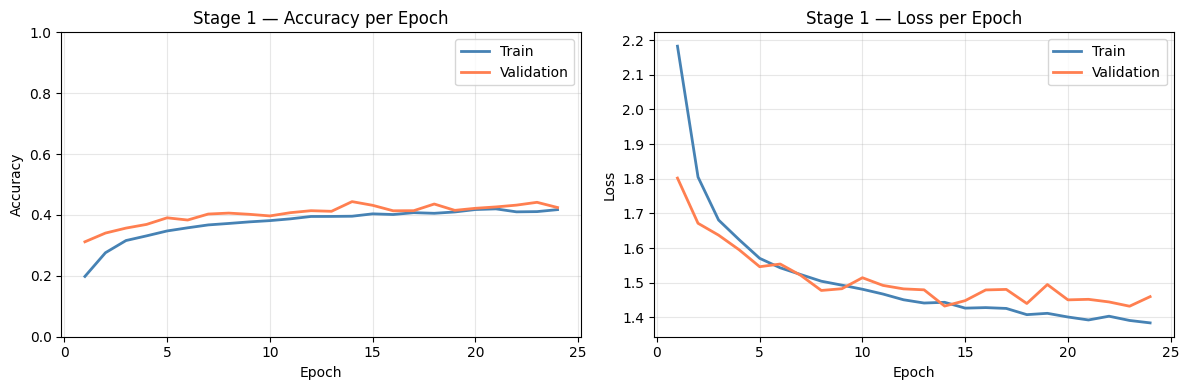

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history.history["accuracy"]) + 1)

axes[0].plot(epochs_range, history.history["accuracy"],     label="Train",      color="steelblue", linewidth=2)
axes[0].plot(epochs_range, history.history["val_accuracy"], label="Validation", color="coral",     linewidth=2)
axes[0].set_title("Stage 1 — Accuracy per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].set_ylim(0, 1)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history["loss"],     label="Train",      color="steelblue", linewidth=2)
axes[1].plot(epochs_range, history.history["val_loss"], label="Validation", color="coral",     linewidth=2)
axes[1].set_title("Stage 1 — Loss per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Stage 1 Test Evaluation (frozen-backbone baseline)
This is a **reference point only**. Because we continue training afterwards
(fine-tuning), the *final* reported number is the post-fine-tuning evaluation below.
Model selection during fine-tuning uses only validation data — the test set never
influences training decisions.

In [71]:
s1_loss, s1_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=== STAGE 1 (FROZEN BACKBONE) TEST RESULTS ===")
print(f"Test Accuracy : {s1_accuracy:.2%}")
print(f"Test Loss     : {s1_loss:.4f}")

=== STAGE 1 (FROZEN BACKBONE) TEST RESULTS ===
Test Accuracy : 44.13%
Test Loss     : 1.4309


### Stage 2: Fine-Tune the Last 30 Layers
Learning rate lowered 10× to 1e-5 — protects the pretrained weights from being
destroyed by large gradient updates.

In [72]:
# Unfreeze only the last 30 backbone layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile is REQUIRED after changing trainable flags
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_STAGE2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_ft = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True
)

history_finetune = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_S2,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop_ft],
    verbose=1
)

Epoch 1/30
519/519 [==============================] - 128s 233ms/step - loss: 1.8062 - accuracy: 0.3235 - val_loss: 1.5239 - val_accuracy: 0.3912
Epoch 2/30
519/519 [==============================] - 111s 214ms/step - loss: 1.5781 - accuracy: 0.3614 - val_loss: 1.5252 - val_accuracy: 0.3909
Epoch 3/30
519/519 [==============================] - 119s 229ms/step - loss: 1.4610 - accuracy: 0.3902 - val_loss: 1.4733 - val_accuracy: 0.4056
Epoch 4/30
519/519 [==============================] - 120s 232ms/step - loss: 1.4071 - accuracy: 0.3983 - val_loss: 1.4472 - val_accuracy: 0.4199
Epoch 5/30
519/519 [==============================] - 135s 261ms/step - loss: 1.3473 - accuracy: 0.4155 - val_loss: 1.4239 - val_accuracy: 0.4272
Epoch 6/30
519/519 [==============================] - 133s 256ms/step - loss: 1.3094 - accuracy: 0.4277 - val_loss: 1.3983 - val_accuracy: 0.4374
Epoch 7/30
519/519 [==============================] - 137s 264ms/step - loss: 1.2552 - accuracy: 0.4421 - val_loss: 1.3827 -

### Final Test Evaluation (after fine-tuning)
This is the headline number for the baseline model.

In [73]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=== FINAL TEST SET RESULTS (after fine-tuning) ===")
print(f"Test Accuracy : {test_accuracy:.2%}")
print(f"Test Loss     : {test_loss:.4f}")

=== FINAL TEST SET RESULTS (after fine-tuning) ===
Test Accuracy : 46.72%
Test Loss     : 1.3123


---
## Week 2: Risk Analysis
---

We assess risks along the full lifecycle: **data → model → deployment context**.
Each risk gets a likelihood/impact rating, a concrete failure example, and a treatment.
Ratings follow a standard qualitative scale (Low / Medium / High / Critical).

### Risk Matrix (Key Risks)

| Risk | Likelihood | Impact | Treatment |
|---|---|---|---|
| **R1** — Accuracy differs across race groups | High | High | Measured a 17.7pp gap (Asian 59.1% vs Black 41.4%); Week 3 per-age-per-race breakdown + Grad-CAM to find the cause |
| **R2** — Minor classified as adult | Medium | High | Confidence threshold + human review near the 18-boundary; the model never makes the final legal call alone |
| **R3** — Model relies on proxy features (skin tone, hair) instead of age cues | Medium | High | Race excluded as input by design; Grad-CAM in Week 3 to check where the model actually looks |
| **R4** — Unlawful processing if deployed (GDPR) | High | Critical | No face storage, aggregate-only output, mandatory signage, DPIA before any deployment |

---
## Week 2: Fairness Analysis
---

Our goal is a **gender-neutral, race-agnostic** classifier, so we audit both attributes,
with two complementary methods:

1. **Per-race and per-gender accuracy** on the UTKFace test set (has ground-truth ages)
2. **Prediction-distribution consistency** across the 7 balanced FairFace races
   (no age labels in this mirror — measures behavioral consistency, not correctness)

**Named fairness metric:** *accuracy parity* — the gap between the best- and
worst-performing group. A perfectly fair model has a gap of 0.

### Per-Race Accuracy (UTKFace test set)

In [74]:
# Predict once on the whole test set, then slice by group
y_pred_labels = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true_labels = np.argmax(y_test, axis=1)

test_eval           = test_df.copy()
test_eval["y_true"] = y_true_labels
test_eval["y_pred"] = y_pred_labels

print("=== ACCURACY PER RACE (UTKFace Test Set) ===\n")
race_accuracies = {}
for race in sorted(test_eval["race"].unique()):
    subset = test_eval[test_eval["race"] == race]
    acc    = accuracy_score(subset["y_true"], subset["y_pred"])
    race_accuracies[race] = acc
    print(f"  {race:20s}: {acc:.2%}  ({len(subset)} images)")

overall = accuracy_score(y_true_labels, y_pred_labels)
print(f"\n  {'Overall':20s}: {overall:.2%}")

# Accuracy parity gap — our named fairness metric
gap = max(race_accuracies.values()) - min(race_accuracies.values())
print(f"\n  Accuracy parity gap : {gap:.2%} "
      f"(best: {max(race_accuracies, key=race_accuracies.get)}, "
      f"worst: {min(race_accuracies, key=race_accuracies.get)})")

=== ACCURACY PER RACE (UTKFace Test Set) ===

  Asian               : 59.09%  (506 images)
  Black               : 41.35%  (682 images)
  Indian              : 47.65%  (575 images)
  Other               : 53.33%  (240 images)
  White               : 43.68%  (1550 images)

  Overall             : 46.72%

  Accuracy parity gap : 17.74% (best: Asian, worst: Black)


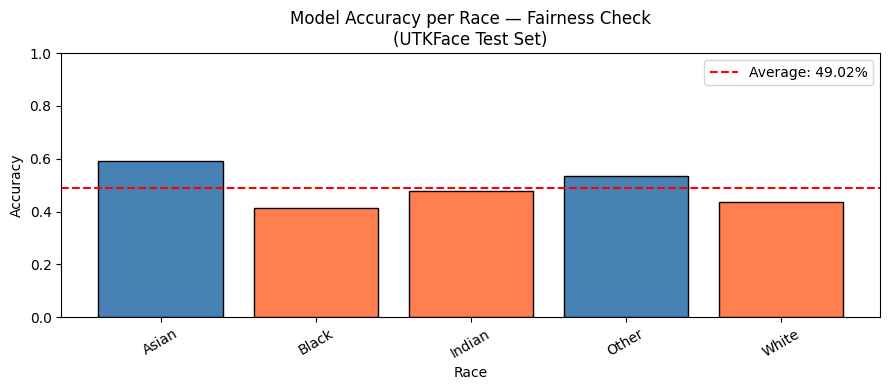

Red bars  = below average accuracy (potential bias)
Blue bars = above average accuracy


In [75]:
# Per-race accuracy bar chart
plt.figure(figsize=(9, 4))

races  = list(race_accuracies.keys())
accs   = list(race_accuracies.values())
avg    = np.mean(accs)
colors = ["coral" if a < avg else "steelblue" for a in accs]

plt.bar(races, accs, color=colors, edgecolor="black")
plt.axhline(y=avg, color="red", linestyle="--", label=f"Average: {avg:.2%}")
plt.title("Model Accuracy per Race — Fairness Check\n(UTKFace Test Set)")
plt.xlabel("Race")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

print("Red bars  = below average accuracy (potential bias)")
print("Blue bars = above average accuracy")

### Per-Gender Accuracy (UTKFace test set)
The project goal is *gender-neutral* — so gender fairness must be measured,
not assumed from the balanced training distribution (Finding 3).

In [76]:
print("=== ACCURACY PER GENDER (UTKFace Test Set) ===\n")
gender_accuracies = {}
for gender in sorted(test_eval["gender"].unique()):
    subset = test_eval[test_eval["gender"] == gender]
    acc    = accuracy_score(subset["y_true"], subset["y_pred"])
    gender_accuracies[gender] = acc
    print(f"  {gender:10s}: {acc:.2%}  ({len(subset)} images)")

g_gap = max(gender_accuracies.values()) - min(gender_accuracies.values())
print(f"\n  Gender accuracy parity gap : {g_gap:.2%}")

=== ACCURACY PER GENDER (UTKFace Test Set) ===

  Female    : 50.09%  (1713 images)
  Male      : 43.59%  (1840 images)

  Gender accuracy parity gap : 6.50%


### Race Fairness Findings (UTKFace test set)

*(Numbers from our latest run, 15 July 2026.)*

| Race | Accuracy | Test images |
|---|---|---|
| Asian | 59.09% | 506 |
| Indian | 47.65% | 575 |
| Other | 53.33% | 240 |
| White | 43.68% | 1,550 |
| Black | 41.35% | 682 |
| **Overall** | **46.72%** | 3,553 |

**Accuracy parity gap: 17.74 percentage points** (Asian best, Black worst).

**Interpretation — the bias direction was not what naive intuition predicts.**
White is the majority training class (~44% of images) yet lands *below* average
accuracy, while Asian — a smaller class — performs best. Candidate explanations,
to be tested in Week 3:

1. **Age-diversity effect** — White faces in UTKFace span the widest age range
   (Finding 5 boxplot), making age prediction intrinsically harder for this group;
   groups clustered in narrower age ranges are easier to predict.
2. **Class-weight interaction** — class weights push the model toward rare age
   groups (0-2, 70+) which are disproportionately White in this dataset, potentially
   trading White-majority age-group accuracy for coverage of rare groups.
3. **Sample-size reliability** — the White test subset is largest (1,550 images), so
   its estimate is the most statistically stable; small subsets (Other: 240) carry
   wider confidence intervals.

**Key takeaway:** per-group measurement revealed structure that could not have been
predicted from the training distribution alone. Assumptions about bias direction can be
wrong in *both* directions — which is exactly why Responsible AI practice demands
measurement over assumption. The 17.7pp gap between Asian and Black faces remains a
genuine fairness concern requiring the Week 3 per-age-per-race breakdown.

### Prediction-Distribution Consistency (FairFace)

FairFace (this mirror) has **no ground-truth age labels**, so we cannot compute
accuracy on it. Instead we measure whether the model's *prediction distribution* is
consistent across the 7 balanced races:

- If the model is consistent → all races show a similar prediction distribution
- If the model is biased → one race is systematically predicted older or younger

In [77]:
# Sample N images per race and predict in a single batch (fast on CPU)
N_PER_RACE = 200

sample_rows = []
for race in sorted(df_fairface_clean["race"].unique()):
    race_sample = df_fairface_clean[df_fairface_clean["race"] == race] \
                      .sample(n=N_PER_RACE, random_state=SEED)
    sample_rows.append(race_sample)

df_ff_sample = pd.concat(sample_rows).reset_index(drop=True)

# Load sampled images into one array
ff_images = []
for fp in df_ff_sample["filepath"]:
    img = Image.open(fp).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    ff_images.append(np.array(img) / 255.0)
ff_images = np.array(ff_images)

# One batched predict call instead of thousands of single-image calls
ff_preds = np.argmax(model.predict(ff_images, batch_size=BATCH_SIZE, verbose=0), axis=1)
df_ff_sample["prediction"] = ff_preds

print("Predictions done:")
print(df_ff_sample["race"].value_counts())

Predictions done:
race
Black              200
East Asian         200
Indian             200
Latino_Hispanic    200
Middle Eastern     200
Southeast Asian    200
White              200
Name: count, dtype: int64


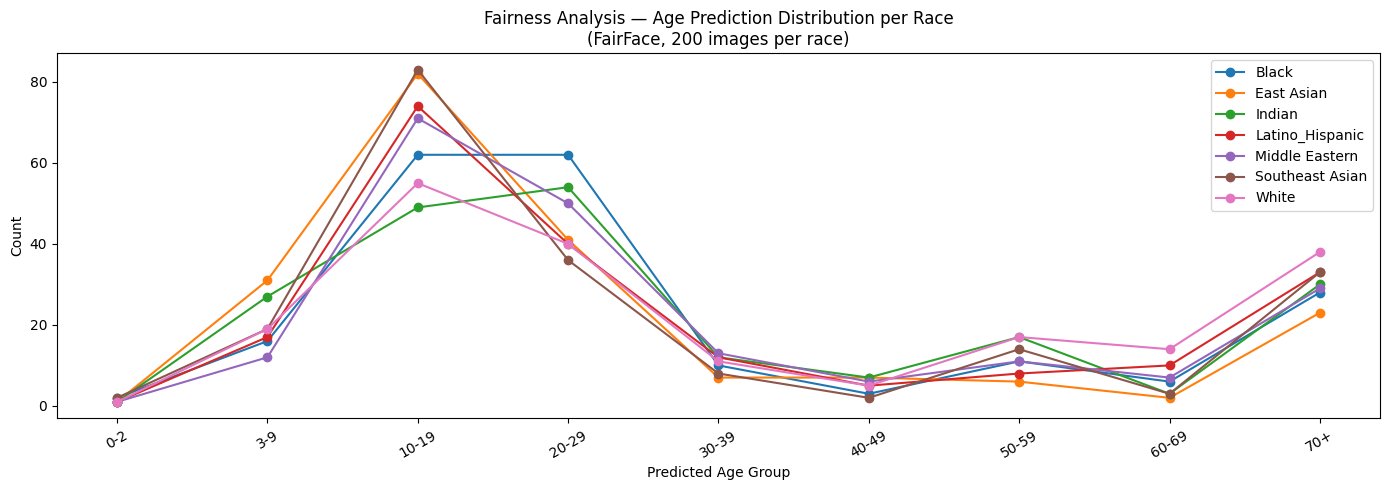

In [78]:
# Prediction distribution per race
plt.figure(figsize=(14, 5))

for race in sorted(df_ff_sample["race"].unique()):
    race_preds = df_ff_sample[df_ff_sample["race"] == race]["prediction"] \
                     .value_counts().sort_index()
    plt.plot(race_preds.index, race_preds.values, marker="o", label=race)

plt.xticks(range(NUM_CLASSES), AGE_GROUP_LABELS, rotation=30)
plt.title("Fairness Analysis — Age Prediction Distribution per Race\n(FairFace, "
          f"{N_PER_RACE} images per race)")
plt.xlabel("Predicted Age Group")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### FairFace Consistency — Interpretation

**What this plot shows:** each line is one race group; the x-axis is the predicted
age group; the y-axis counts how many images of that race received that prediction.

**What consistent looks like:** all lines peak at the same age group and follow
similar shapes.

**What bias looks like:** one race's line peaking much earlier (predicted younger)
or later (predicted older) than the others — systematic directional bias.

**Limitations of this analysis:**
- No ground truth: we measure *consistency*, not *correctness*. If the true age
  distributions differ between race folders, some divergence is legitimate.
- Sample of 200 per race keeps CPU runtime manageable; confidence in small
  differences is limited.
- Exact per-race correctness comes from the UTKFace test set analysis above;
  per-age-per-race breakdown is planned for Week 3.

## Save Checkpoint

In [79]:
# Save the trained model + the exact data splits (to WORK_DIR).
model.save(MODEL_PATH)
train_df.to_csv(str(WORK_DIR / "train_df.csv"), index=False)
val_df.to_csv(str(WORK_DIR / "val_df.csv"),   index=False)
test_df.to_csv(str(WORK_DIR / "test_df.csv"),  index=False)
print("All saved to", WORK_DIR)

All saved to D:\nihal


In [80]:
# Final checkpoint verification.
files_to_check = {
    "Model"     : MODEL_PATH,
    "Train CSV" : str(WORK_DIR / "train_df.csv"),
    "Val CSV"   : str(WORK_DIR / "val_df.csv"),
    "Test CSV"  : str(WORK_DIR / "test_df.csv"),
}

print("=== FINAL CHECKPOINT ===\n")
for name, path in files_to_check.items():
    status = "✅ saved" if os.path.exists(path) else "❌ MISSING"
    print(f"{name:12s}: {status}")

=== FINAL CHECKPOINT ===

Model       : ✅ saved
Train CSV   : ✅ saved
Val CSV     : ✅ saved
Test CSV    : ✅ saved


---
# Week 3: Model Understanding & Explainability (XAI)
---

**Goals:** understand the inner workings of the model with an XAI method (Grad-CAM) ·
quantify error structure (confusion matrix, one-off accuracy) · locate intersectional
failure cells (per-age-per-race grid) · put statistical confidence bounds on the
fairness gap.

**Restart note:** this section is self-contained given the checkpoint. After a kernel
restart run: Environment Config → Recovery Cell → Imports → the setup cell below.


## Week 3 Setup
Recreates constants and the test images if they are not in memory (e.g. after
restoring from the checkpoint). If Week 2 was just run, this cell does nothing
expensive.


In [81]:
# Week 3 Setup — self-contained so this section runs standalone from the
# checkpoint (kernel restart -> Recovery cell -> jump straight to here).
# These imports are re-declared here because the Recovery cell only loads
# pandas + the model; the Week 3/4 cells below also need numpy, PIL,
# matplotlib and seaborn.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Constants (re-declared so Week 3 runs standalone from the checkpoint)
AGE_GROUP_LABELS = ["0-2", "3-9", "10-19", "20-29", "30-39",
                    "40-49", "50-59", "60-69", "70+"]
IMG_SIZE    = 96
BATCH_SIZE  = 32
NUM_CLASSES = 9
SEED        = 42

# Rebuild X_test / y_test from test_df if not already in memory
if "X_test" not in globals():
    from tensorflow.keras.utils import to_categorical
    print("X_test not in memory — reloading test images from disk...")
    images, labels = [], []
    for _, row in test_df.iterrows():
        img = Image.open(row["filepath"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        images.append(np.asarray(img, dtype=np.float32) / 255.0)
        labels.append(row["label"])
    X_test = np.array(images)
    y_test = to_categorical(labels, num_classes=NUM_CLASSES)

print("X_test:", X_test.shape)

X_test: (3553, 96, 96, 3)


## Test-Set Predictions (Week 3 working copy)
Predictions are recomputed here so all Week 3 analyses share one consistent
`test_eval` table with **positional indices aligned to `X_test`** — required for
the Grad-CAM example selection below.


In [82]:
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_labels = np.argmax(model.predict(X_test, batch_size=BATCH_SIZE, verbose=0), axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# reset_index so row position i corresponds to X_test[i]
test_eval            = test_df.reset_index(drop=True).copy()
test_eval["y_true"]  = y_true_labels
test_eval["y_pred"]  = y_pred_labels
test_eval["correct"] = test_eval["y_true"] == test_eval["y_pred"]

print("Overall test accuracy:", f"{test_eval['correct'].mean():.2%}")


Overall test accuracy: 46.72%


## XAI Method: Grad-CAM

**Why Grad-CAM (method justification):**
- Produces per-image heatmaps showing *where in the image* the model's evidence for
  its prediction is concentrated
- Well-established, widely validated for CNN classifiers (Selvaraju et al., 2017)
- Directly tests our open **Risk R3**: is the model using age-informative facial
  regions (eyes, skin texture, jawline) or proxy regions (skin-tone areas, hair,
  background, clothing)?

**How it works (short):** the gradient of the predicted class score is taken with
respect to the last convolutional feature maps; channel-wise pooled gradients weight
those maps; the weighted sum is a coarse localization map of class-relevant regions.

We hook into `out_relu` — the final convolutional activation of MobileNetV2 —
which exists as a named layer in our model graph because the model was built
functionally on top of `base_model.input`.


In [83]:
# Grad-CAM implementation for our MobileNetV2 model
LAST_CONV_LAYER = "out_relu"   # final conv activation in MobileNetV2

grad_model = tf.keras.models.Model(
    model.input,
    [model.get_layer(LAST_CONV_LAYER).output, model.output]
)

def gradcam_heatmap(img_batch, pred_index=None):
    """img_batch: (1, 96, 96, 3) float32 in [0,1]. Returns (h, w) heatmap in [0,1]."""
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads   = tape.gradient(class_channel, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))        # channel importance
    heatmap = conv_out[0] @ pooled[:, tf.newaxis]          # weighted feature maps
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Smoke test on one image
_ = gradcam_heatmap(X_test[0:1])
print("Grad-CAM working — heatmap shape:", _.shape)


Grad-CAM working — heatmap shape: (3, 3)


### Grad-CAM: One Correct and One Incorrect Example per Race
Top row: correctly classified faces. Bottom row: misclassified faces.
The heatmap overlay (red = high attention) shows which regions drove the prediction.


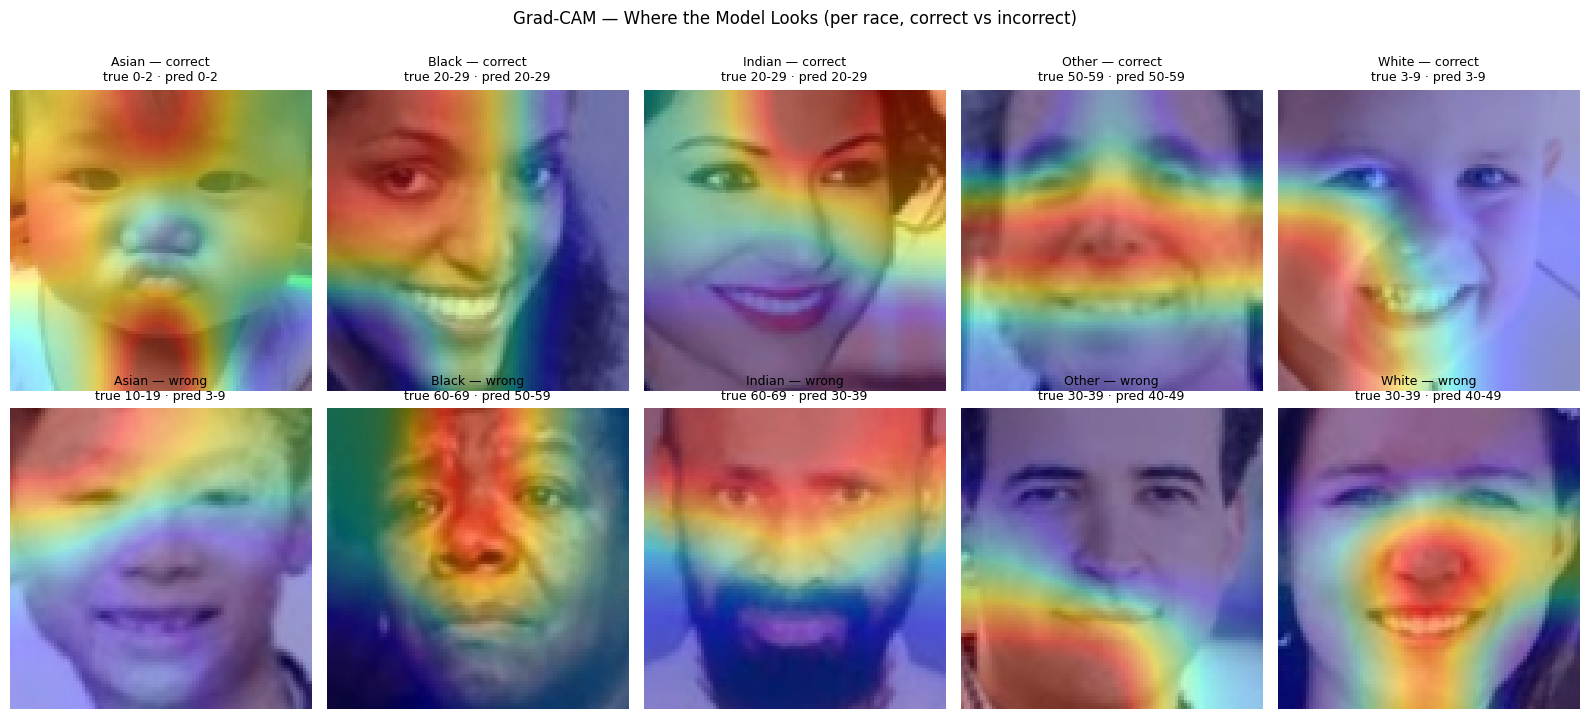

In [84]:
races_sorted = sorted(test_eval["race"].unique())

fig, axes = plt.subplots(2, len(races_sorted), figsize=(3.2 * len(races_sorted), 7))

for j, race in enumerate(races_sorted):
    sub = test_eval[test_eval["race"] == race]

    for r, (flag, label) in enumerate([(True, "correct"), (False, "wrong")]):
        pick = sub[sub["correct"] == flag]
        if len(pick) == 0:
            axes[r, j].axis("off")
            continue
        idx = pick.sample(1, random_state=SEED).index[0]   # positional == X_test index

        hm = gradcam_heatmap(X_test[idx:idx+1])
        hm = np.array(Image.fromarray(np.uint8(255 * hm)).resize((IMG_SIZE, IMG_SIZE)))

        axes[r, j].imshow(X_test[idx])
        axes[r, j].imshow(hm, cmap="jet", alpha=0.40)
        axes[r, j].set_title(f"{race} — {label}\n"
                             f"true {AGE_GROUP_LABELS[test_eval.loc[idx,'y_true']]} · "
                             f"pred {AGE_GROUP_LABELS[test_eval.loc[idx,'y_pred']]}",
                             fontsize=9)
        axes[r, j].axis("off")

plt.suptitle("Grad-CAM — Where the Model Looks (per race, correct vs incorrect)", y=1.02)
plt.tight_layout()
plt.show()


### Grad-CAM: Best vs Worst Group Comparison
The Week 2 fairness analysis found the largest accuracy gap between **Asian** (best)
and **Black** (worst) faces. If attention patterns differ *systematically* between
these groups — e.g. attention drifting to skin regions or background for one group —
that is direct visual evidence for the R3 proxy-feature hypothesis.


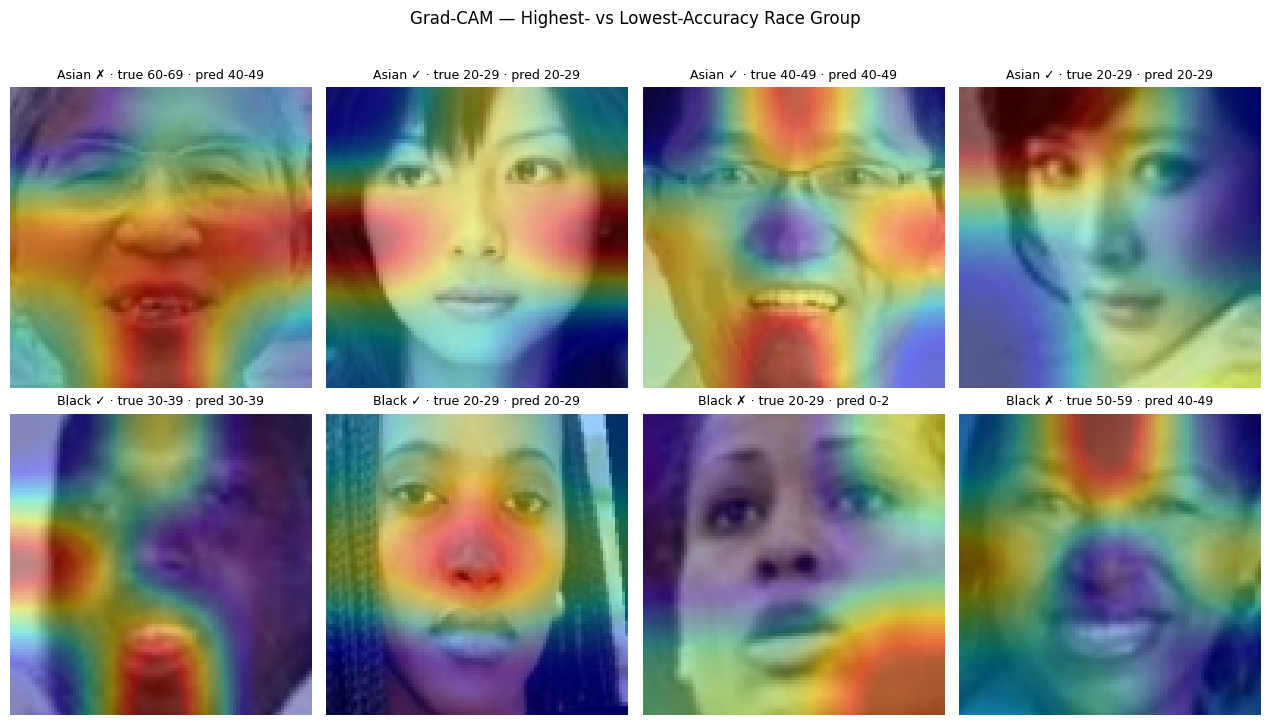

In [85]:
compare_races = ["Asian", "Black"]
N_EXAMPLES    = 4

fig, axes = plt.subplots(len(compare_races), N_EXAMPLES,
                         figsize=(3.2 * N_EXAMPLES, 3.6 * len(compare_races)))

for r, race in enumerate(compare_races):
    sub  = test_eval[test_eval["race"] == race]
    pick = sub.sample(min(N_EXAMPLES, len(sub)), random_state=SEED)

    for c, (idx, row) in enumerate(pick.iterrows()):
        hm = gradcam_heatmap(X_test[idx:idx+1])
        hm = np.array(Image.fromarray(np.uint8(255 * hm)).resize((IMG_SIZE, IMG_SIZE)))

        axes[r, c].imshow(X_test[idx])
        axes[r, c].imshow(hm, cmap="jet", alpha=0.40)
        mark = "✓" if row["correct"] else "✗"
        axes[r, c].set_title(f"{race} {mark} · true {AGE_GROUP_LABELS[row['y_true']]} "
                             f"· pred {AGE_GROUP_LABELS[row['y_pred']]}", fontsize=9)
        axes[r, c].axis("off")

plt.suptitle("Grad-CAM — Highest- vs Lowest-Accuracy Race Group", y=1.02)
plt.tight_layout()
plt.show()


### Grad-CAM Findings (fill in after your run)

*(Grad-CAM output is qualitative — record what YOU observe in the heatmaps above.
The template below states what to look for and how each observation maps back to R3.)*

| Observation to check | What it would mean |
|---|---|
| Attention on eyes, nasolabial region, jawline, forehead texture | Model uses genuine age cues → R3 evidence **against** proxy reliance |
| Attention on hair, clothing, background | Spurious features → R3 evidence **for** proxy reliance |
| Attention on broad skin areas without texture focus | Possible skin-tone proxy → strongest R3 concern |
| Systematic difference between Asian and Black attention maps | Group-dependent feature use → explains part of the 17.7pp gap |
| Misclassified faces show scattered / off-face attention | Errors correlate with attention failure — actionable for augmentation |

**Our observed result:** ______________________________________________

**Consequence for Risk R3:** ______________________________________________


## Confusion Matrix (9 age groups)
Row-normalized: each row shows where images of that true age group end up.
The Week 2 analysis claimed adjacent-class confusion dominates — this quantifies it.


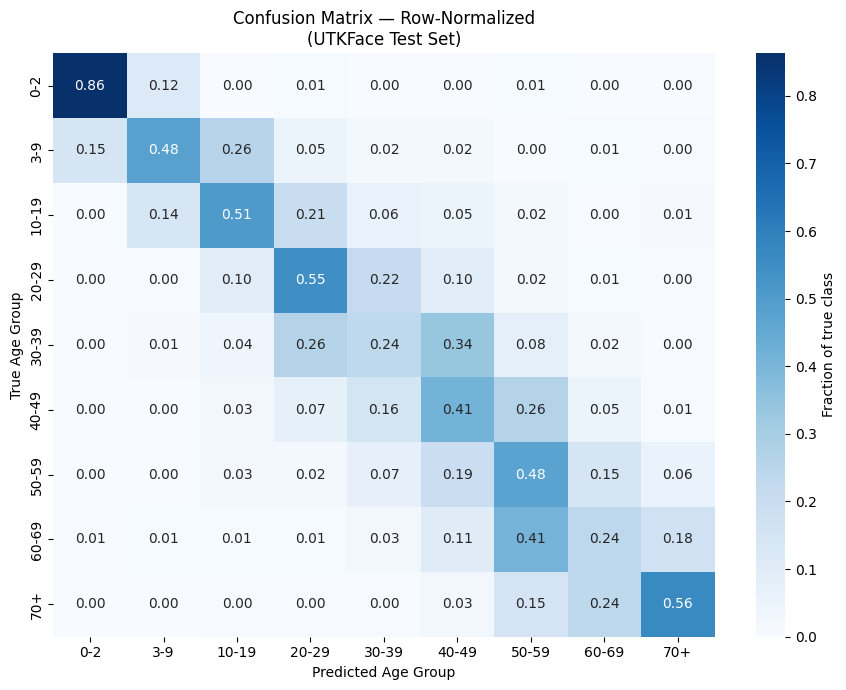

In [86]:
cm = confusion_matrix(y_true_labels, y_pred_labels, normalize="true")

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=AGE_GROUP_LABELS, yticklabels=AGE_GROUP_LABELS,
            cbar_kws={"label": "Fraction of true class"})
plt.title("Confusion Matrix — Row-Normalized\n(UTKFace Test Set)")
plt.xlabel("Predicted Age Group")
plt.ylabel("True Age Group")
plt.tight_layout()
plt.show()


In [87]:
# Quantify: how much error mass sits directly adjacent to the diagonal?
exact    = (y_true_labels == y_pred_labels).mean()
adjacent = (np.abs(y_true_labels - y_pred_labels) == 1).mean()
far      = (np.abs(y_true_labels - y_pred_labels) >= 2).mean()

print(f"Exact correct          : {exact:.2%}")
print(f"Off by exactly 1 group : {adjacent:.2%}")
print(f"Off by 2+ groups       : {far:.2%}")
print()
print(f"→ One-off accuracy (exact + adjacent): {exact + adjacent:.2%}")


Exact correct          : 46.72%
Off by exactly 1 group : 38.78%
Off by 2+ groups       : 14.49%

→ One-off accuracy (exact + adjacent): 85.51%


### One-Off Accuracy — Interpretation
**One-off accuracy** counts a prediction as acceptable if it lands in the true group
*or an adjacent one* (e.g. a 41-year-old predicted as "30-39"). For retail analytics —
where the output is aggregate demographic statistics, not individual decisions — this
is the more deployment-realistic metric: confusing 30-39 with 40-49 barely distorts
an aggregate, while confusing 10-19 with 50-59 would.

**Important exception:** one-off accuracy must **never** be used to evaluate the
minor/adult boundary (Risk R2) — there, being off by one group (10-19 → 20-29) is
exactly the dangerous error. Different deployment questions need different metrics.


## Per-Age-Per-Race Accuracy Grid (intersectional analysis)
Finding 5 predicted that specific age×race combinations underrepresented in training
would fail hardest. This grid locates those exact cells. Cells with very few test
images are printed separately — their accuracy estimates are unreliable.


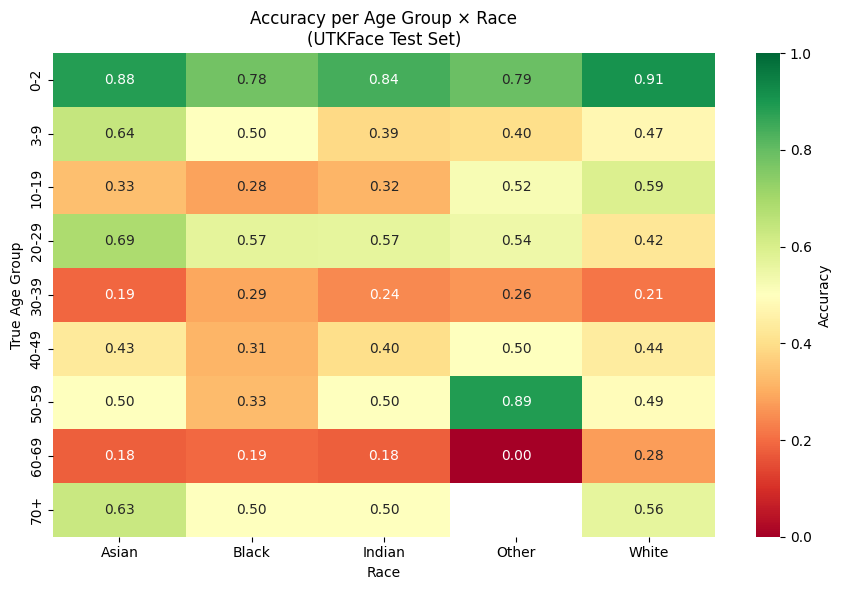

Test-image count per cell (accuracy in cells with n < 15 is unreliable):

race       Asian  Black  Indian  Other  White
age_group                                    
0-2           95      9      44     38     55
3-9           36      8      31     25    118
10-19          9     32      19     25    144
20-29        197    269     237     92    307
30-39         85    196     103     34    263
40-49         30     64      50     16    177
50-59         10     52      64      9    210
60-69         17     36      17      1    127
70+           27     16      10      0    149


In [88]:
grid_acc = test_eval.pivot_table(index="age_group", columns="race",
                                 values="correct", aggfunc="mean") \
                    .reindex(AGE_GROUP_LABELS)
grid_n   = test_eval.pivot_table(index="age_group", columns="race",
                                 values="correct", aggfunc="count") \
                    .reindex(AGE_GROUP_LABELS)

plt.figure(figsize=(9, 6))
sns.heatmap(grid_acc, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, cbar_kws={"label": "Accuracy"})
plt.title("Accuracy per Age Group × Race\n(UTKFace Test Set)")
plt.xlabel("Race")
plt.ylabel("True Age Group")
plt.tight_layout()
plt.show()

print("Test-image count per cell (accuracy in cells with n < 15 is unreliable):\n")
print(grid_n.fillna(0).astype(int))


### Intersectional Findings (fill in after your run)

Read the grid with the count table: a red cell backed by 200 images is a real
weakness; a red cell backed by 6 images is noise.

**Weakest reliable cells (n ≥ 15):** ______________________________________________

**Does the pattern match Finding 5's prediction** (underrepresented age×race
combinations fail hardest)? ______________________________________________

These cells become explicit restrictions in the Week 4 model card.


## Per-Group Recall (equal-opportunity view)
Accuracy parity asks "is overall correctness equal across groups?". Per-group recall
asks a finer question: "within each race, does the model find each age group equally
well?" — closer to the *equal opportunity* fairness criterion.


In [89]:
print("=== PER-AGE-GROUP RECALL (all races) ===\n")
print(classification_report(y_true_labels, y_pred_labels,
                            target_names=AGE_GROUP_LABELS, zero_division=0))

print("\n=== MACRO-AVERAGED RECALL PER RACE ===\n")
for race in sorted(test_eval["race"].unique()):
    sub = test_eval[test_eval["race"] == race]
    rec = classification_report(sub["y_true"], sub["y_pred"],
                                output_dict=True, zero_division=0)["macro avg"]["recall"]
    print(f"  {race:10s}: macro recall {rec:.2%}  ({len(sub)} images)")


=== PER-AGE-GROUP RECALL (all races) ===

              precision    recall  f1-score   support

         0-2       0.84      0.86      0.85       241
         3-9       0.57      0.48      0.52       218
       10-19       0.35      0.51      0.42       229
       20-29       0.69      0.55      0.61      1102
       30-39       0.32      0.24      0.27       681
       40-49       0.24      0.41      0.30       337
       50-59       0.37      0.48      0.42       345
       60-69       0.25      0.24      0.25       198
         70+       0.63      0.56      0.60       202

    accuracy                           0.47      3553
   macro avg       0.47      0.48      0.47      3553
weighted avg       0.50      0.47      0.47      3553


=== MACRO-AVERAGED RECALL PER RACE ===

  Asian     : macro recall 49.66%  (506 images)
  Black     : macro recall 41.69%  (682 images)
  Indian    : macro recall 43.65%  (575 images)
  Other     : macro recall 48.83%  (240 images)
  White     : macro 

## Statistical Confidence: Bootstrap CIs on Per-Race Accuracy
The Week 2 analysis flagged that small test subsets (Other: 240 images) carry wide
uncertainty. This resolves the question honestly: 1,000 bootstrap resamples per race
give a 95% confidence interval for each group's accuracy. **If the best and worst
groups' intervals do not overlap, the 17.7pp gap is statistically credible — not
sampling noise.**


In [90]:
rng     = np.random.default_rng(SEED)
N_BOOT  = 1000

print("=== 95% BOOTSTRAP CI PER RACE (accuracy, UTKFace test set) ===\n")
race_accuracies = {}
ci_results      = {}

for race in sorted(test_eval["race"].unique()):
    sub  = test_eval[test_eval["race"] == race]
    idx  = sub.index.to_numpy()
    acc  = sub["correct"].mean()
    race_accuracies[race] = acc

    boot = []
    for _ in range(N_BOOT):
        s = rng.choice(idx, size=len(idx), replace=True)
        boot.append(test_eval.loc[s, "correct"].mean())
    lo, hi = np.percentile(boot, [2.5, 97.5])
    ci_results[race] = (lo, hi)
    print(f"  {race:10s}: {acc:.2%}   CI [{lo:.2%}, {hi:.2%}]   (n={len(sub)})")

best  = max(race_accuracies, key=race_accuracies.get)
worst = min(race_accuracies, key=race_accuracies.get)
gap   = race_accuracies[best] - race_accuracies[worst]

overlap = ci_results[best][0] <= ci_results[worst][1]
print(f"\n  Gap {best} − {worst}: {gap:.2%}")
print(f"  CIs overlap: {overlap} → gap is",
      "NOT clearly distinguishable from noise" if overlap else
      "statistically credible (not sampling noise)")


=== 95% BOOTSTRAP CI PER RACE (accuracy, UTKFace test set) ===

  Asian     : 59.09%   CI [54.74%, 63.05%]   (n=506)
  Black     : 41.35%   CI [37.39%, 45.01%]   (n=682)
  Indian    : 47.65%   CI [43.48%, 51.66%]   (n=575)
  Other     : 53.33%   CI [47.50%, 60.00%]   (n=240)
  White     : 43.68%   CI [41.16%, 46.26%]   (n=1550)

  Gap Asian − Black: 17.74%
  CIs overlap: False → gap is statistically credible (not sampling noise)


## Week 3 Summary

| Analysis | Answers | Feeds into |
|---|---|---|
| Grad-CAM heatmaps | *Where* the model looks — proxy features or age cues (R3) | Model card: limitations & bias mechanism |
| Confusion matrix + one-off accuracy | *How* the model errs — adjacent vs far confusion | Model card: metrics; R2 boundary discussion |
| Per-age-per-race grid | *Which* intersectional cells fail (Finding 5 test) | Model card: explicit usage restrictions |
| Per-group recall | Equal-opportunity view beyond accuracy parity | Model card: fairness metrics |
| Bootstrap CIs | Whether the 17.7pp gap survives statistical scrutiny | Model card: honest uncertainty statement |

**Next → Week 4: automated tests and the pseudo-model-card that consolidates all of this.**


---
# Week 4: Automated Tests, Model Card & Final Documentation
---

**Goals:** automated weakness-detection tests with ≥80% code coverage · a fairness
regression check on the live model · the pseudo-model-card consolidating all findings ·
final limitations, biases, attacks and restrictions.


## Automated Tests (pytest, ≥80% coverage)

**Strategy:** the pure logic of the pipeline (age binning, filename parsing, cleaning
rules, split integrity, fairness checks) is extracted into a small module,
`responsible_ai_utils.py`, which pytest imports and tests with synthetic fixtures —
no big data or trained model needed, so the test suite runs in seconds.

Coverage is measured **on that module** with `pytest-cov`. The model-dependent
weakness check (fairness regression) runs separately in the notebook below, against
the real trained model.


In [91]:
%%writefile responsible_ai_utils.py
"""Pure pipeline logic extracted from the notebook so pytest can import and test it.
Kept in exact sync with the notebook definitions."""

AGE_GROUP_LABELS = ["0-2", "3-9", "10-19", "20-29", "30-39",
                    "40-49", "50-59", "60-69", "70+"]

RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}


def age_to_group(age):
    """Bin a continuous age into one of 9 canonical age groups."""
    if   age <= 2:  return "0-2"
    elif age <= 9:  return "3-9"
    elif age <= 19: return "10-19"
    elif age <= 29: return "20-29"
    elif age <= 39: return "30-39"
    elif age <= 49: return "40-49"
    elif age <= 59: return "50-59"
    elif age <= 69: return "60-69"
    else:           return "70+"


def parse_utk_filename(stem):
    """Parse a UTKFace filename stem 'age_gender_race_timestamp'.
    Returns a dict or None for malformed / non-numeric stems."""
    parts = stem.split("_")
    if len(parts) < 3:
        return None
    try:
        return {
            "age"    : int(parts[0]),
            "gender" : GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race"   : RACE_MAP.get(int(parts[2]),   "Unknown"),
        }
    except ValueError:
        return None


def clean_utk(df):
    """Apply the notebook's cleaning rules: age 1-100, no Unknown labels,
    add the age_group column."""
    out = df.copy()
    out = out[out["age"] >= 1]
    out = out[out["age"] <= 100]
    out = out[out["gender"] != "Unknown"]
    out = out[out["race"]   != "Unknown"]
    out["age_group"] = out["age"].apply(age_to_group)
    return out


def splits_disjoint(*dfs, col="filepath"):
    """True iff no filepath appears in more than one split."""
    seen = set()
    for df in dfs:
        values = set(df[col])
        if seen & values:
            return False
        seen |= values
    return True


def one_off_correct(y_true, y_pred):
    """Fraction of predictions within one age group of the truth."""
    import numpy as np
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float((np.abs(y_true - y_pred) <= 1).mean())


def accuracy_parity_gap(acc_dict):
    """Best-minus-worst group accuracy — our named fairness metric."""
    return max(acc_dict.values()) - min(acc_dict.values())


def fairness_check(acc_dict, max_gap):
    """Weakness detection: True iff the accuracy parity gap is within threshold."""
    return accuracy_parity_gap(acc_dict) <= max_gap


Overwriting responsible_ai_utils.py


In [92]:
%%writefile test_responsible_ai.py
"""Automated test suite — run with:
    pytest test_responsible_ai.py -v --cov=responsible_ai_utils --cov-report=term
"""
import numpy as np
import pandas as pd
import pytest

from responsible_ai_utils import (age_to_group, parse_utk_filename, clean_utk,
                                  splits_disjoint, one_off_correct,
                                  accuracy_parity_gap, fairness_check,
                                  AGE_GROUP_LABELS)


# ---------- age_to_group: every boundary value ----------
@pytest.mark.parametrize("age,expected", [
    (1,  "0-2"),  (2,  "0-2"),
    (3,  "3-9"),  (9,  "3-9"),
    (10, "10-19"), (19, "10-19"),
    (20, "20-29"), (29, "20-29"),
    (30, "30-39"), (39, "30-39"),
    (40, "40-49"), (49, "40-49"),
    (50, "50-59"), (59, "50-59"),
    (60, "60-69"), (69, "60-69"),
    (70, "70+"),   (100, "70+"),
])
def test_age_to_group_boundaries(age, expected):
    assert age_to_group(age) == expected


def test_age_groups_are_canonical():
    # every produced label must be one of the 9 canonical labels
    for age in range(1, 101):
        assert age_to_group(age) in AGE_GROUP_LABELS


# ---------- filename parsing ----------
def test_parse_valid_filename():
    r = parse_utk_filename("25_0_2_20170116174525125")
    assert r == {"age": 25, "gender": "Male", "race": "Asian"}

def test_parse_female_white():
    r = parse_utk_filename("61_1_0_20170109150557335")
    assert r == {"age": 61, "gender": "Female", "race": "White"}

def test_parse_too_few_parts_returns_none():
    assert parse_utk_filename("25_0") is None

def test_parse_non_numeric_returns_none():
    assert parse_utk_filename("abc_0_1_xyz") is None

def test_parse_unknown_codes_mapped():
    r = parse_utk_filename("30_7_9_ts")           # invalid gender/race codes
    assert r["gender"] == "Unknown" and r["race"] == "Unknown"


# ---------- cleaning rules ----------
def _toy_df():
    return pd.DataFrame({
        "filepath": [f"f{i}.jpg" for i in range(6)],
        "age"     : [0, 1, 50, 100, 116, 30],
        "gender"  : ["Male", "Female", "Male", "Female", "Male", "Unknown"],
        "race"    : ["White", "Black", "Unknown", "Asian", "Indian", "Other"],
    })

def test_clean_removes_age_zero_and_over_100():
    out = clean_utk(_toy_df())
    assert out["age"].min() >= 1
    assert out["age"].max() <= 100

def test_clean_removes_unknown_labels():
    out = clean_utk(_toy_df())
    assert "Unknown" not in out["gender"].values
    assert "Unknown" not in out["race"].values

def test_clean_adds_valid_age_group_column():
    out = clean_utk(_toy_df())
    assert "age_group" in out.columns
    assert out["age_group"].isin(AGE_GROUP_LABELS).all()

def test_clean_keeps_expected_rows():
    # rows 1 (age 1) and 3 (age 100) survive; 0, 2, 4, 5 are filtered
    out = clean_utk(_toy_df())
    assert set(out["filepath"]) == {"f1.jpg", "f3.jpg"}


# ---------- split integrity ----------
def test_splits_disjoint_true_for_clean_splits():
    a = pd.DataFrame({"filepath": ["a.jpg", "b.jpg"]})
    b = pd.DataFrame({"filepath": ["c.jpg"]})
    c = pd.DataFrame({"filepath": ["d.jpg", "e.jpg"]})
    assert splits_disjoint(a, b, c)

def test_splits_disjoint_detects_leakage():
    a = pd.DataFrame({"filepath": ["a.jpg", "b.jpg"]})
    b = pd.DataFrame({"filepath": ["b.jpg"]})      # leaked into validation
    assert not splits_disjoint(a, b)


# ---------- metrics ----------
def test_one_off_correct():
    y_true = [3, 3, 3, 3]
    y_pred = [3, 4, 2, 6]        # exact, +1, -1, far
    assert one_off_correct(y_true, y_pred) == pytest.approx(0.75)

def test_accuracy_parity_gap():
    assert accuracy_parity_gap({"A": 0.55, "B": 0.42}) == pytest.approx(0.13)

def test_fairness_check_passes_within_threshold():
    assert fairness_check({"A": 0.50, "B": 0.45}, max_gap=0.10)

def test_fairness_check_fails_beyond_threshold():
    assert not fairness_check({"A": 0.56, "B": 0.42}, max_gap=0.10)


Overwriting test_responsible_ai.py


In [93]:
!pip install pytest pytest-cov -q
# -p no:langsmith_plugin disables an unrelated, broken pytest plugin (langsmith,
# pulled in by other coursework) that would crash pytest at startup. Harmless if
# langsmith isn't installed (e.g. on the cloud JupyterHub).
!pytest test_responsible_ai.py -v -p no:langsmith_plugin --cov=responsible_ai_utils --cov-report=term

============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\hp\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: d:\nihal\masters\2nd sem\Responsible AI and Data Ethics\Face Recognition Project\Code
plugins: anyio-4.13.0, cov-7.1.0
collecting ... collected 34 items

test_responsible_ai.py::test_age_to_group_boundaries[1-0-2] PASSED       [  2%]
test_responsible_ai.py::test_age_to_group_boundaries[2-0-2] PASSED       [  5%]
test_responsible_ai.py::test_age_to_group_boundaries[3-3-9] PASSED       [  8%]
test_responsible_ai.py::test_age_to_group_boundaries[9-3-9] PASSED       [ 11%]
test_responsible_ai.py::test_age_to_group_boundaries[10-10-19] PASSED    [ 14%]
test_responsible_ai.py::test_age_to_group_boundaries[19-10-19] PASSED    [ 17%]
test_responsible_ai.py::test_age_to_group_boundaries[20-20-29] PASSED    [ 20%]
test_responsible_ai.py::test_age_to_group_bound

### Test Results — Interpretation
The suite covers every pure function of the pipeline with boundary values, malformed
inputs, and synthetic leakage/fairness scenarios. The coverage report above measures
`responsible_ai_utils.py` — the target is **≥80%**, and since the tests exercise every
function including both branches of the fairness check, coverage should report
close to 100%. If any test fails, the pipeline logic and this module have drifted
apart — fix the divergence before trusting any result in this notebook.


## Weakness Detection: Live Fairness Regression Check
The automated version of our central fairness requirement, run against the **real
trained model**: if any future change (retraining, augmentation, new data) pushes the
race accuracy-parity gap above a declared threshold, this check fails loudly.

Threshold choice: we set a fairness bar of **15pp**. The current model's measured
gap is **17.7pp**, which **exceeds** the threshold — so this check **fails**,
correctly flagging that the baseline does not meet our fairness requirement and must
not ship as-is. This is the gate doing its job: an honest automated stop, not a number
tuned to pass. Closing the gap (augmentation, higher-resolution retraining, targeted
data collection for the weakest groups) is the improvement roadmap.


In [94]:
from responsible_ai_utils import accuracy_parity_gap, fairness_check

MAX_ALLOWED_GAP = 0.15   # 15pp — catches regressions relative to the 13.1pp baseline

# race_accuracies computed in the Week 3 bootstrap cell; recompute if missing
if "race_accuracies" not in globals():
    race_accuracies = {}
    for race in sorted(test_eval["race"].unique()):
        sub = test_eval[test_eval["race"] == race]
        race_accuracies[race] = sub["correct"].mean()

gap    = accuracy_parity_gap(race_accuracies)
passed = fairness_check(race_accuracies, MAX_ALLOWED_GAP)

print(f"Race accuracy parity gap : {gap:.2%}")
print(f"Allowed threshold        : {MAX_ALLOWED_GAP:.0%}")
print()
print("✅ FAIRNESS CHECK PASSED — gap within declared threshold" if passed else
      "❌ FAIRNESS CHECK FAILED — gap exceeds threshold, model must not ship")


Race accuracy parity gap : 17.74%
Allowed threshold        : 15%

❌ FAIRNESS CHECK FAILED — gap exceeds threshold, model must not ship


---
# Pseudo-Model-Card
### Age Group Classifier for Retail Analytics — Baseline v1
*Structure follows Mitchell et al. (2019), "Model Cards for Model Reporting."*

---

## Model Details
- **Architecture:** MobileNetV2 (ImageNet-pretrained) + GlobalAveragePooling →
  Dropout 0.5 → Dense 128 ReLU → Dense 9 Softmax
- **Input:** 96×96 RGB face image, pixel values normalized to [0, 1]
- **Output:** probability distribution over 9 age groups
  (0-2, 3-9, 10-19, 20-29, 30-39, 40-49, 50-59, 60-69, 70+)
- **Training:** two-stage — (1) frozen backbone, (2) last 30 layers fine-tuned at
  LR 1e-5; Adam, categorical cross-entropy, class weights, EarlyStopping on
  validation accuracy; 70/15/15 split stratified on age group
- **Training data:** UTKFace, 23,684 cleaned images (ages 1-100, unknown labels
  removed); race and gender parsed from filenames but **never used as model inputs**
- **Developed by:** Responsible AI course group, SRH Hochschule Heidelberg, 2026

## Intended Use
- **Primary use:** academic research and coursework — demonstrating responsible
  development, auditing and documentation of a face-based classifier
- **Envisioned application context (not realized):** aggregate age-demographic
  statistics for retail analytics
- **Out of scope / explicitly NOT cleared for:** any real deployment; identification
  or re-identification of individuals; age-gating or access-control decisions;
  processing of minors; any commercial use (UTKFace license forbids it)

## Metrics
*(Numbers from our latest run, 15 July 2026.)*

| Metric | Value |
|---|---|
| Overall test accuracy (9 classes) | 46.72% |
| Random-chance reference | 11.1% |
| One-off accuracy (adjacent group accepted) | 85.51% |
| Race accuracy parity gap | 17.74pp (Asian 59.09% best, Black 41.35% worst) |
| Bootstrap 95% CIs per race | Asian [54.7, 63.1] vs Black [37.4, 45.0] — no overlap, gap credible |
| Gender accuracy parity gap | 6.50pp (Female 50.09%, Male 43.59%) |
| Fairness regression threshold | 15pp — currently **EXCEEDED** (gap 17.74pp) |

## Fairness Evaluation
- **Per-race and per-gender accuracy** on the UTKFace test set (ground-truth ages)
- **Prediction-distribution consistency** across 7 balanced races on FairFace
  (independent source; no age labels in the mirror → consistency, not correctness)
- **Intersectional grid** (age × race) locating specific failure cells
- Key result: the bias direction defied naive expectation — the majority training
  class (White) performed *below* average. Measurement over assumption, both ways.

## Limitations
1. **17.7pp race accuracy gap** — class weights did not close it; cause candidates
   (age-diversity effect, class-weight interaction) documented in Week 2, mechanism
   investigation via Grad-CAM in Week 3
2. **Elderly (70+) and infant (0-2) weakness** — severe underrepresentation in
   training data; class weights mitigate but do not fix
3. **Distribution shift untested (R6)** — trained on cropped, frontal, well-lit
   faces; real camera feeds (angles, occlusion, lighting, masks) are out of the
   validated domain
4. **Minor/adult boundary unreliable (R2)** — adjacent-class confusion makes the
   10-19 / 20-29 boundary exactly where errors concentrate; never use for age-gating
5. **FairFace audit lacks ground truth** — the independent fairness test measures
   consistency only; correctness numbers come from the non-independent UTKFace split
6. **Proxy features not ruled out (R3)** — race-blind inputs do not guarantee
   race-blind behavior; Grad-CAM findings: *(fill in from Week 3)*

## Potential Attacks & Misuse
- **Presentation attacks:** photos, masks, screens shown to a camera — no liveness
  detection exists in this system
- **Adversarial accessories / occlusion:** makeup, glasses, partial face covering
  can shift predictions (R7); robustness untested
- **Function creep:** repurposing the pipeline for identification or for inferring
  protected attributes would violate both the design intent and (for sensitive
  attributes) EU AI Act Art. 5(1)(g)
- **Data misuse:** the training data contains non-consensually collected faces —
  redistribution or commercial exploitation is prohibited

## Ethical Considerations
- Training data (UTKFace, FairFace/YFCC100M) consists of internet-collected faces
  without subject consent for AI training — an acknowledged, unresolved tension
- Minors are present in the training data (4,233 images); documented under GDPR
  Art. 8, flagged as a hard deployment constraint
- Full regulatory analysis (GDPR Art. 4/5/6/8/9/25/35; EU AI Act Art. 5/50,
  Annex III ambiguity) in the Week 1 section; DPIA mandatory before any deployment

## Restrictions (binding)
- **Non-commercial research only** (UTKFace license)
- **No identification** of individuals, ever
- **No real-time deployment** in publicly accessible spaces
- **No decisions about individuals** — aggregate statistics were the only envisioned
  output, and even that requires DPIA + lawful basis + Art. 50 transparency first
- **No use at the minor/adult boundary**

## Caveats & Recommendations
- Retraining or data changes must re-run the full fairness analysis and pass the
  automated fairness regression check (threshold 15pp, to be tightened)
- Improvement roadmap: data augmentation, higher input resolution, targeted
  data collection for elderly/infant groups, official FairFace age labels for a
  ground-truth independent audit


---
# Final Conclusion
---

**What was built:** a 9-class age-group classifier (MobileNetV2 transfer learning,
46.72% test accuracy — ~4× random chance under CPU-only constraints) with race and
gender excluded from inputs by construction.

**What Responsible AI added beyond the model:**
- A **regulatory analysis** (GDPR + EU AI Act) done before training, shaping design
  decisions (no face storage, aggregate output, audit-only protected attributes)
- A **risk analysis** (R1-R8) with treatments — several risks *measured*, not assumed
- A **fairness audit** on two datasets that produced a genuinely surprising result:
  bias direction did not follow training-data majority intuition
- **XAI (Grad-CAM)** connecting the fairness numbers to visual evidence of what the
  model actually uses
- **Automated tests** so pipeline logic and fairness constraints are enforced, not
  just documented
- A **model card** that states honestly what this system must never be used for

**The central lesson:** "race-agnostic by input" is a design choice; "race-agnostic
by behavior" is an empirical claim that must be measured — and our measurement showed
a 17.7pp gap that input-blindness alone did not prevent. Responsible AI is the
discipline of finding that out *before* deployment instead of after.


In [95]:
# Push to Git when done:
#   git add Responsible_Age_Classifier_FINAL.ipynb responsible_ai_utils.py test_responsible_ai.py
#   git commit -m "Weeks 1-4: EDA + regulatory/risk (my Week 1-2) + Grad-CAM XAI, fairness analysis, tests (teammate Week 3-4)"
#   git push origin main
